# RenAIssance OCR Pipeline: Transformer-based Text Recognition for 17th-Century Spanish Printed Documents

**GSoC 2026 Evaluation Task — Test I: Printed Documents**

---

## 1. Introduction

### Problem Statement

Historical document OCR is a substantially harder problem than modern document OCR. Challenges include:

- **Typeface variation**: 17th-century Spanish printers used a mix of Roman, Italic, and Gothic typefaces, often within the same page, with irregular kerning and ligatures (`fi`, `fl`, `ff`, `ct`, `st`) that no longer exist in modern fonts.
- **Orthographic conventions**: u/v interchange, long-s (ʃ), ç = modern z, abbreviation marks (tildes, superscript letters), and archaic word forms.
- **Physical degradation**: faded ink, staining, bleed-through from the reverse side, and paper foxing are common in century-old paper.
- **Scanning artefacts**: microfilm rescans introduce additional noise, vignetting, and contrast issues.

### Dataset

Six printed Spanish documents from the 17th century (Test I — Printed category), paired with ground-truth transcriptions following diplomatic transcription conventions (preserving original spelling).

### Architecture

**Primary pipeline (TrOCR + fine-tuning):**
```
PDF → [PyMuPDF 300 DPI] → Page Images
   → [Preprocessing: deskew + CLAHE + denoise + Sauvola binarisation]
   → [CRAFT text detector] → Line bounding boxes
   → [TrOCR (microsoft/trocr-large-printed) fine-tuned with LoRA] → Raw OCR text
   → [Gemini 2.5 Flash text correction] → Cleaned OCR text
   → [jiwer / sacrebleu] → CER / WER / BLEU evaluation
```

**Parallel evaluation paths:**
```
Page Images → [Surya OCR (zero-shot, 2024)] → Transcribed text → Evaluation
Page Images → [CRAFT line crops] → [Gemini 2.5 Flash Vision direct transcription] → Evaluation
```

**Architecture motivation:**
- **TrOCR** (Li et al., 2021) uses a ViT encoder and an autoregressive transformer decoder — a direct implementation of the ViT-TF architecture specified in the task. The `trocr-large-printed` checkpoint has a strong prior over printed character shapes and word boundaries.
- **CRAFT** (Baek et al., CVPR 2019) produces character-level region heatmaps robust to irregular spacing, decorative initials, and marginalia in historical documents.
- **Surya OCR** (Paruchuri, 2024) is evaluated as a zero-shot parallel track. It includes its own BLLA-based layout detection and supports 90+ languages with no fine-tuning required.
- **Gemini 2.5 Flash** is used in two modes: (a) as an LLM post-processor that corrects OCR artefacts while preserving historical orthography, and (b) as a VLM that transcribes line images directly — treating the language model as the OCR engine itself.

## 2. Setup

Environment detection, dependency installation, and GPU configuration. We pin `transformers==4.56.1` for compatibility with both TrOCR and Surya.

In [1]:
# Detect environment (Kaggle vs. Colab)
import os
import sys
    
IS_KAGGLE = os.path.exists('/kaggle')
IS_COLAB  = 'google.colab' in sys.modules
print(f"Environment: {'Kaggle' if IS_KAGGLE else 'Colab' if IS_COLAB else 'Local'}")

Environment: Kaggle


In [2]:
!pip install torch torchvision peft accelerate datasets evaluate PyMuPDF Pillow opencv-python-headless albumentations scikit-image jiwer sacrebleu python-docx google-generativeai matplotlib seaborn pandas tqdm pyyaml scipy -q              
!pip install PyMuPDF python-docx -q                                                                                                                                                                                                            
!pip install transformers==4.56.1 --force-reinstall -q                                                                                                                                                                                         
!pip install "numpy==2.2.6" -q 

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.25.1 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
ydata-profiling 4.18.1 requires numpy<2.4,>=1.22, but you have numpy 2.4.3 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.4.3 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy

In [3]:
import sys
for key in list(sys.modules.keys()):
  if 'transformers' in key:
      del sys.modules[key]

#import transformers.utils.import_utils as _tf_iu
#_tf_iu.is_scipy_available = lambda: False

#import transformers.utils as _tf_utils                                                                                                                                                                                                         
#_tf_utils.is_scipy_available = lambda: False 

import transformers
print(transformers.__version__)

4.56.1


In [4]:
import scipy
from sklearn.metrics import roc_curve

In [5]:
import scipy
print(scipy.__version__)

1.16.3


In [6]:
import numpy
print(numpy.__version__)

2.2.6


In [7]:
import subprocess as _sp
_r = _sp.run(['pip', 'install', 'surya-ocr', '-q', '--no-build-isolation'])
SURYA_AVAILABLE = _r.returncode == 0
print(f"surya-ocr: {'✓ installed' if SURYA_AVAILABLE else '✗ unavailable (Section 6.5 will be skipped)'}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.5/48.5 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 189.9/189.9 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 MB 37.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 85.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 94.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 226.4/226.4 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.4/99.4 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.8/5.8 MB 114.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 469.0/469.0 kB 28.9 MB/s eta 0:00:00
surya-ocr: ✓ installed


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.


In [8]:
# Mount data
if IS_KAGGLE:
    DATA_ROOT   = '/kaggle/input/datasets/anmolsen24/renaissance-ocr-data/task-dataset'
    SRC_ROOT    = '/kaggle/input/datasets/anmolsen24/renaissance-ocr-data/src'
    RESULTS_DIR = '/kaggle/working/results'
    CKPT_DIR    = '/kaggle/working/checkpoints'
elif IS_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    DATA_ROOT   = '/content/drive/MyDrive/renaissance-ocr/task-dataset'
    SRC_ROOT    = '/content/drive/MyDrive/renaissance-ocr/src'
    RESULTS_DIR = '/content/drive/MyDrive/renaissance-ocr/results'
    CKPT_DIR    = '/content/drive/MyDrive/renaissance-ocr/checkpoints'
else:
    DATA_ROOT   = '../task-dataset'
    SRC_ROOT    = '../src'
    RESULTS_DIR = '../results'
    CKPT_DIR    = '../checkpoints'

sys.path.insert(0, SRC_ROOT)

PRINT_SOURCES = os.path.join(DATA_ROOT, 'Test sources', 'Print')
PRINT_GT      = os.path.join(DATA_ROOT, 'Test transcriptions', 'Print')
HW_SOURCES    = os.path.join(DATA_ROOT, 'Test sources', 'Handwriting')
HW_GT         = os.path.join(DATA_ROOT, 'Test transcriptions', 'Handwriting')

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(CKPT_DIR, exist_ok=True)

print(f"Sources (Print) : {PRINT_SOURCES}")
print(f"GT (Print)      : {PRINT_GT}")
print(f"Sources (HW)    : {HW_SOURCES}")
print(f"GT (HW)         : {HW_GT}")
print(f"Results dir     : {RESULTS_DIR}")
print(f"Checkpoint dir  : {CKPT_DIR}")


Sources (Print) : /kaggle/input/datasets/anmolsen24/renaissance-ocr-data/task-dataset/Test sources/Print
GT (Print)      : /kaggle/input/datasets/anmolsen24/renaissance-ocr-data/task-dataset/Test transcriptions/Print
Sources (HW)    : /kaggle/input/datasets/anmolsen24/renaissance-ocr-data/task-dataset/Test sources/Handwriting
GT (HW)         : /kaggle/input/datasets/anmolsen24/renaissance-ocr-data/task-dataset/Test transcriptions/Handwriting
Results dir     : /kaggle/working/results
Checkpoint dir  : /kaggle/working/checkpoints


In [9]:
import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'
n_gpus = torch.cuda.device_count()
print(f"Device: {device}  |  GPUs available: {n_gpus}")
if device == 'cuda':
    for i in range(n_gpus):
        props = torch.cuda.get_device_properties(i)
        print(f"  GPU {i}: {props.name}  |  VRAM: {props.total_memory / 1e9:.1f} GB")
    total_vram = sum(torch.cuda.get_device_properties(i).total_memory for i in range(n_gpus))
    print(f"  Total VRAM: {total_vram / 1e9:.1f} GB")
    print(f"\nHuggingFace Trainer will use all {n_gpus} GPU(s) automatically.")

Device: cuda  |  GPUs available: 2
  GPU 0: Tesla T4  |  VRAM: 15.6 GB
  GPU 1: Tesla T4  |  VRAM: 15.6 GB
  Total VRAM: 31.3 GB

HuggingFace Trainer will use all 2 GPU(s) automatically.


In [10]:
import json
import os

# CACHE_DIR for checkpoint JSON files — use CKPT_DIR set in cell 6
CACHE_DIR = CKPT_DIR
os.makedirs(CACHE_DIR, exist_ok=True)

def save_preds(preds, name):
    with open(f'{CACHE_DIR}/{name}.json', 'w') as f:
        json.dump(preds, f, ensure_ascii=False)
    print(f"Saved {name}: {len(preds)} entries")

def load_preds(name):
    path = f'{CACHE_DIR}/{name}.json'
    if os.path.exists(path):
        with open(path) as f:
            return json.load(f)
    return None


## 3. Data Exploration

Load source PDFs and ground-truth transcriptions, align pages to GT entries, and preview the data.

In [11]:
import os
from pathlib import Path

print("=== Print Sources ===")
for f in sorted(os.listdir(PRINT_SOURCES)):
    size = os.path.getsize(os.path.join(PRINT_SOURCES, f)) / 1e6
    print(f"  {f:60s}  {size:.1f} MB")

print("\n=== Ground Truth Transcriptions ===")
for f in sorted(os.listdir(PRINT_GT)):
    print(f"  {f}")

=== Print Sources ===
  Buendia - Instruccion.pdf                                     19.0 MB
  Covarrubias - Tesoro lengua.pdf                               111.7 MB
  Guardiola - Tratado nobleza.pdf                               72.6 MB
  PORCONES.228.38  1646.pdf                                     47.6 MB
  PORCONES.23.5 - 1628.pdf                                      32.0 MB
  PORCONES.748.6  1650.pdf                                      57.3 MB

=== Ground Truth Transcriptions ===
  Buendia - Instruccion transcription.docx
  Covarrubias - Tesoro lengua transcription.docx
  Guardiola - Tratado nobleza transcription.docx
  PORCONES.228.38 - 1646 transcription.docx
  PORCONES.23.5 - 1628 transcription.docx
  PORCONES.748.6  1650 Transcription.docx


In [80]:
from data_utils import load_all_pdfs, load_all_ground_truth, build_dataset_pairs

print("Loading ground truth...")
gt_map = load_all_ground_truth(PRINT_GT)
print(f"Loaded GT for {len(gt_map)} documents.")
for name, pages in gt_map.items():
  print(f"  {name} : {len(pages)} pages annotated")

print("\nLoading PDFs at 150 DPI (GT-covered pages only)...")
pdf_map = load_all_pdfs(PRINT_SOURCES, dpi=150, gt_map=gt_map)
print(f"Loaded {len(pdf_map)} documents.")
for name, pages in pdf_map.items():
  print(f"  {name}: {len(pages)} pages")

# PORCONES.23.5: spread scan — GT covers only left page
for key in list(pdf_map.keys()):
    if 'PORCONES.23' in key:
        entry = pdf_map[key]                                                                                                                                                                                                                           
        if isinstance(entry, dict):                                                                                                                                                                                                                    
            pdf_map[key] = {page_num: img.crop((0, 0, img.width // 2, img.height))
                for page_num, img in entry.items()}                                                                                                                                                                                        
        else:                                                          
            pdf_map[key] = [img.crop((0, 0, img.width // 2, img.height))                                                                                                                                                                               
                for img in entry]    
        print(f"  Cropped {key} to left half ({len(pdf_map[key])} pages)")

Loading ground truth...
Loaded GT for 6 documents.
  Buendia - Instruccion transcription : 3 pages annotated
  Covarrubias - Tesoro lengua transcription : 3 pages annotated
  Guardiola - Tratado nobleza transcription : 3 pages annotated
  PORCONES.228.38 - 1646 transcription : 5 pages annotated
  PORCONES.23.5 - 1628 transcription : 4 pages annotated
  PORCONES.748.6  1650 Transcription : 4 pages annotated

Loading PDFs at 150 DPI (GT-covered pages only)...
  Buendia - Instruccion.pdf: loaded (3 of requested pages)
  Covarrubias - Tesoro lengua.pdf: loaded (3 of requested pages)
  Guardiola - Tratado nobleza.pdf: loaded (3 of requested pages)
  PORCONES.228.38  1646.pdf: loaded (5 of requested pages)
  PORCONES.23.5 - 1628.pdf: loaded (4 of requested pages)
  PORCONES.748.6  1650.pdf: loaded (4 of requested pages)
Loaded 6 documents.
  Buendia - Instruccion: 3 pages
  Covarrubias - Tesoro lengua: 3 pages
  Guardiola - Tratado nobleza: 3 pages
  PORCONES.228.38  1646: 5 pages
  PORCONES

In [ ]:
import os, json
from PIL import Image
from data_utils import load_all_ground_truth, build_dataset_pairs

CACHE_DIR = os.path.join(CKPT_DIR, "page_cache")
if os.path.exists(CACHE_DIR) and any(os.path.isdir(os.path.join(CACHE_DIR, d)) for d in os.listdir(CACHE_DIR)):
    preprocessed_map = {}
    for doc_name in sorted(os.listdir(CACHE_DIR)):
        doc_dir = os.path.join(CACHE_DIR, doc_name)
        if os.path.isdir(doc_dir):
            preprocessed_map[doc_name] = {
                int(f.replace("page_", "").replace(".png", "")): Image.open(os.path.join(doc_dir, f)).copy()
                for f in sorted(os.listdir(doc_dir)) if f.endswith(".png")
            }
    with open(os.path.join(CACHE_DIR, "gt_map.json")) as f:
        raw = json.load(f)
    gt_map = {k: {int(pk): pv for pk, pv in v.items()} for k, v in raw.items()}
    pairs_map = build_dataset_pairs(preprocessed_map, gt_map)
    print("Loaded from cache — skip to model cells")

In [83]:
# Align pages with ground truth
pairs_map = build_dataset_pairs(pdf_map, gt_map)
total_pairs = sum(len(v) for v in pairs_map.values())
print(f"Total page–GT pairs: {total_pairs}")
for name, pairs in pairs_map.items():
    print(f"  {name}: {len(pairs)} aligned pages")

Total page–GT pairs: 22
  Buendia - Instruccion: 3 aligned pages
  Covarrubias - Tesoro lengua: 3 aligned pages
  Guardiola - Tratado nobleza: 3 aligned pages
  PORCONES.228.38  1646: 5 aligned pages
  PORCONES.23.5 - 1628: 4 aligned pages
  PORCONES.748.6  1650: 4 aligned pages


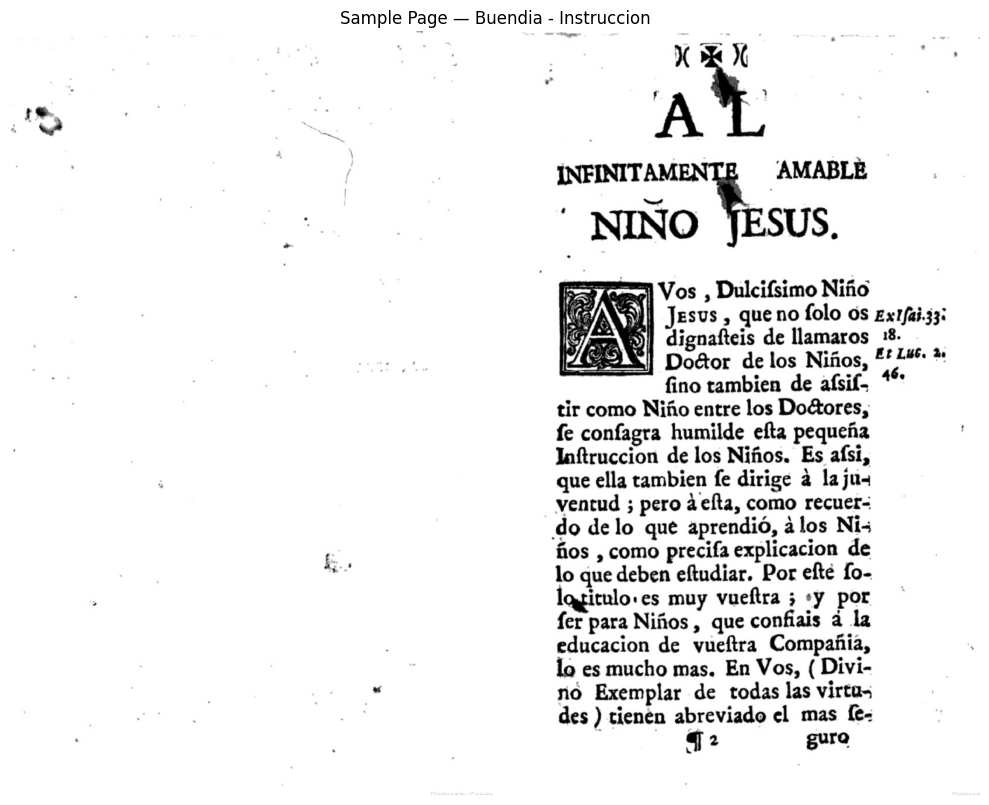


=== Ground Truth (first 500 chars) ===
Al
INFINITAMENTE AMABLE
NIÑO JESUS.
A Vos, Dulcissimo Niño
JESUS, que no solo os
dignasteis de llamaros
Doctor de los Niños, 
sino también de assis-
tir como Niño entre los Doctores, 
se consagra humilde esta pequeña
Instrucción de los Niños. Es assi, 
que ella también se dirige a la ju-
ventud; pero a esta, como recuer-
do de lo que aprendió, a los Ni-
ños, como precisa explicacion de 
lo que deben estudiar. Por este so-
lo titulo es muy vuestra; y por
ser para Niños, que confiais a la
educacio


In [84]:
# Show sample page and its ground truth
import matplotlib.pyplot as plt
import numpy as np

first_doc = list(pairs_map.keys())[0]
sample_img, sample_gt = pairs_map[first_doc][0]

fig, ax = plt.subplots(figsize=(10, 14))
ax.imshow(np.array(sample_img))
ax.set_title(f"Sample Page — {first_doc}", fontsize=12)
ax.axis('off')
plt.tight_layout()
plt.show()

print("\n=== Ground Truth (first 500 chars) ===")
print(sample_gt[:500])

## 4. Preprocessing

The preprocessing chain applies:
1. **CLAHE** — enhances local contrast to compensate for uneven illumination
2. **Deskew** — projection-profile method corrects residual rotation from scanning
3. **Denoising** — non-local means removes scanner noise while preserving strokes
4. **Sauvola binarisation** — adaptive thresholding for non-uniform backgrounds

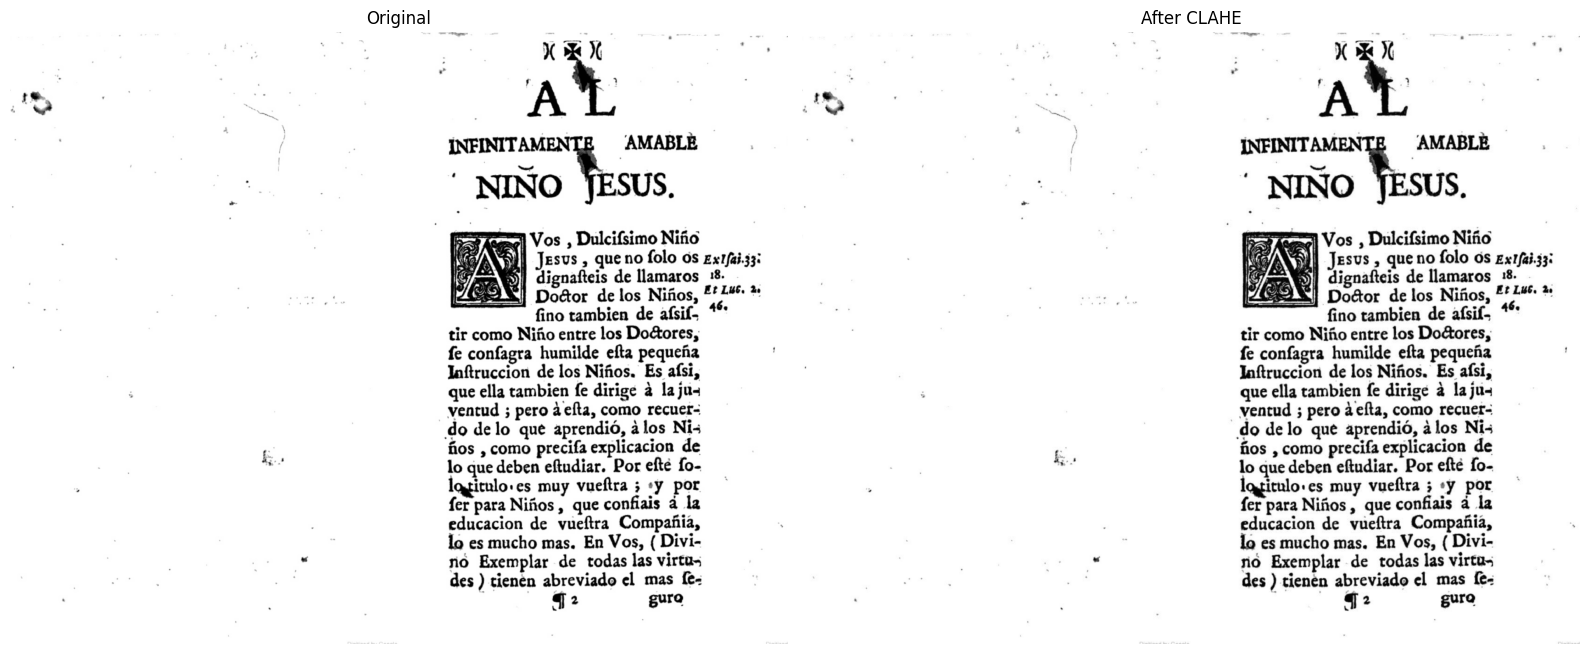

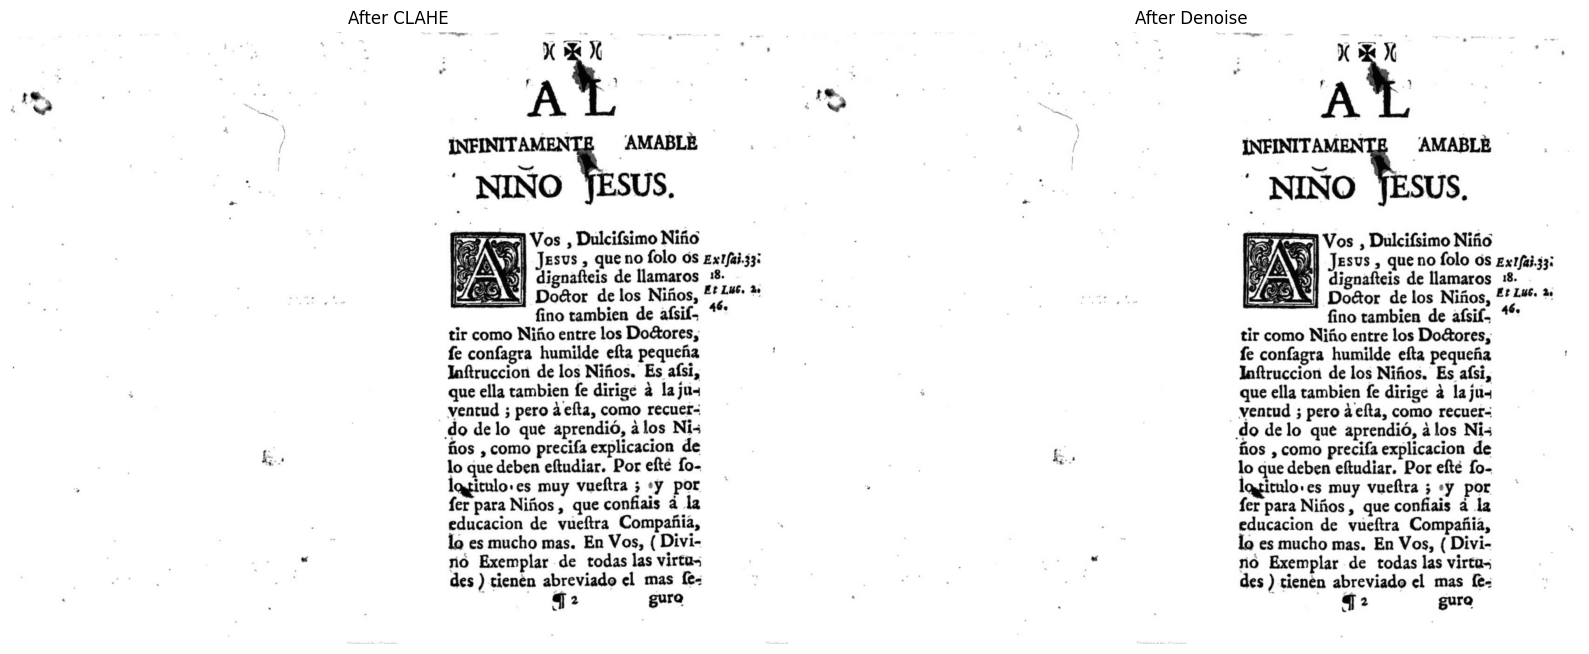

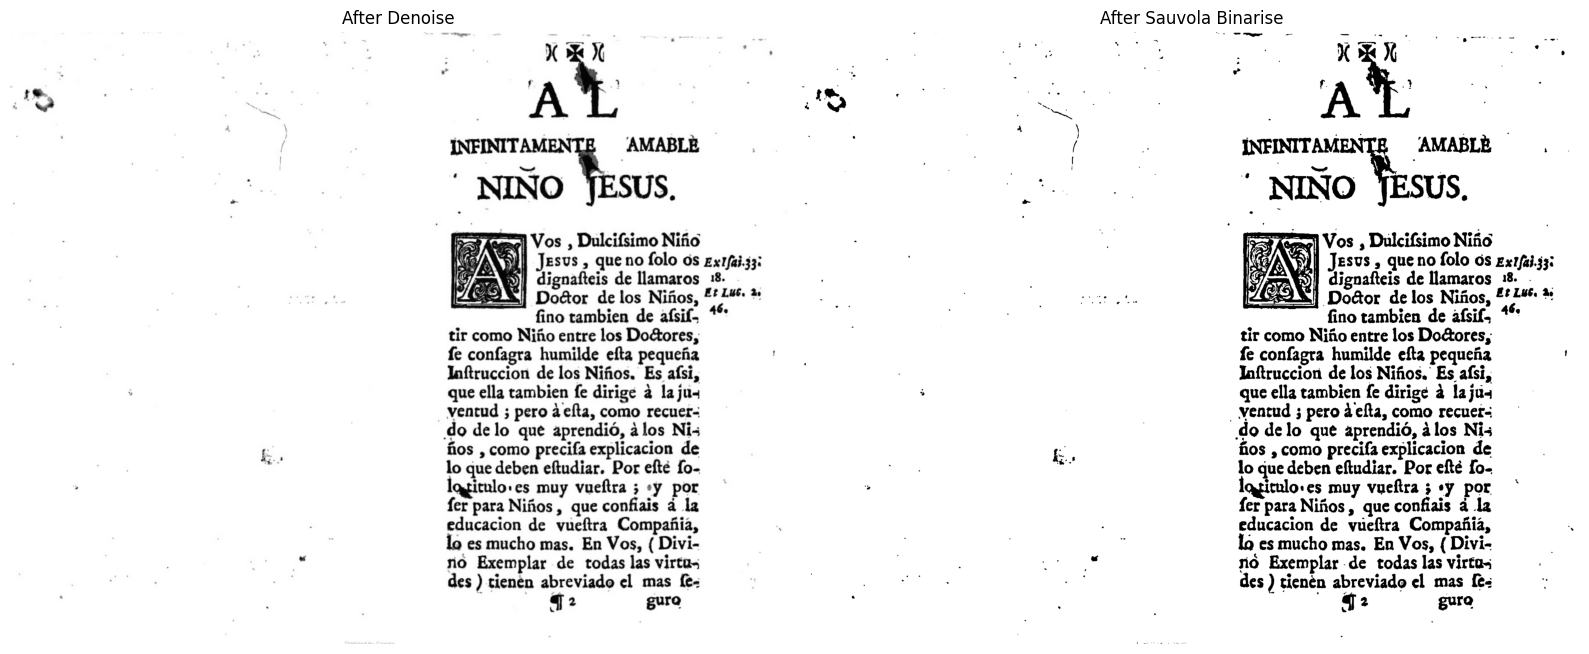

In [85]:
from preprocessing import preprocess_page, deskew, enhance_contrast, denoise, binarize, pil_to_gray, gray_to_pil
from data_utils import show_preprocessing_comparison
import numpy as np

# Demonstrate each step
sample = sample_img

gray = gray_to_pil(pil_to_gray(sample))
clahe_img = gray_to_pil(enhance_contrast(pil_to_gray(sample)))
deskewed_img = gray_to_pil(deskew(pil_to_gray(clahe_img)))
denoised_img = gray_to_pil(denoise(pil_to_gray(deskewed_img)))
binary_img = gray_to_pil(binarize(pil_to_gray(denoised_img)))

show_preprocessing_comparison(sample, clahe_img, ("Original", "After CLAHE"))
show_preprocessing_comparison(clahe_img, denoised_img, ("After CLAHE", "After Denoise"))
show_preprocessing_comparison(denoised_img, binary_img, ("After Denoise", "After Sauvola Binarise"))

In [88]:
# Preprocess all pages (keep grayscale for CRAFT; use RGB for TrOCR)
from preprocessing import preprocess_page
from tqdm import tqdm

preprocessed_map = {}
for doc_name, pages in pdf_map.items():
  if isinstance(pages, dict):
      preprocessed_map[doc_name] = {
          pn: preprocess_page(img, return_gray=True)
          for pn, img in tqdm(pages.items(), desc=doc_name, leave=False)
      }
  else:
      preprocessed_map[doc_name] = [
          preprocess_page(p, return_gray=True)
          for p in tqdm(pages, desc=doc_name, leave=False)
      ]
print("Preprocessing complete.")

Preprocessing complete.


In [17]:
import os, json

CACHE_DIR = os.path.join(CKPT_DIR, "page_cache")
os.makedirs(CACHE_DIR, exist_ok=True)

for doc_name, pages in preprocessed_map.items():
  doc_dir = os.path.join(CACHE_DIR, doc_name)
  os.makedirs(doc_dir, exist_ok=True)
  items = pages.items() if isinstance(pages, dict) else enumerate(pages)
  for pn, img in items:
      img.save(os.path.join(doc_dir, f"page_{pn}.png"))

with open(os.path.join(CACHE_DIR, "gt_map.json"), "w") as f:
  json.dump({k: {str(pk): pv for pk, pv in v.items()} for k, v in gt_map.items()}, f)
print("Cached.")

Cached.


In [89]:
import gc
del pdf_map
pairs_map = build_dataset_pairs(preprocessed_map, gt_map)
gc.collect()
print("Freed original page images.")

Freed original page images.


In [90]:
import ctypes
ctypes.CDLL("libc.so.6").malloc_trim(0)

1

## 5. Text Detection with CRAFT

CRAFT (Baek et al., CVPR 2019) detects text by predicting:
- **Region score map**: probability that a pixel is inside a character
- **Affinity score map**: probability that adjacent characters belong to the same word

These maps are combined to produce character-level and word-level bounding boxes, which we merge into text line segments.

In [86]:
import sys
sys.path.insert(0, '/kaggle/input/datasets/anmolsen24/renaissance-ocr-data/CRAFT')

from text_detection import load_craft_model, detect_text_regions, filter_main_text, crop_line_images
from data_utils import show_page_with_boxes, show_line_crops

weights_path = '/kaggle/input/datasets/anmolsen24/renaissance-ocr-data/craft_mlt_25k.pth'
craft_model = load_craft_model(weights_path, use_cuda=(device == 'cuda'))
print("CRAFT model loaded.")


CRAFT model loaded.


Detected 51 regions → 19 after marginalia filtering


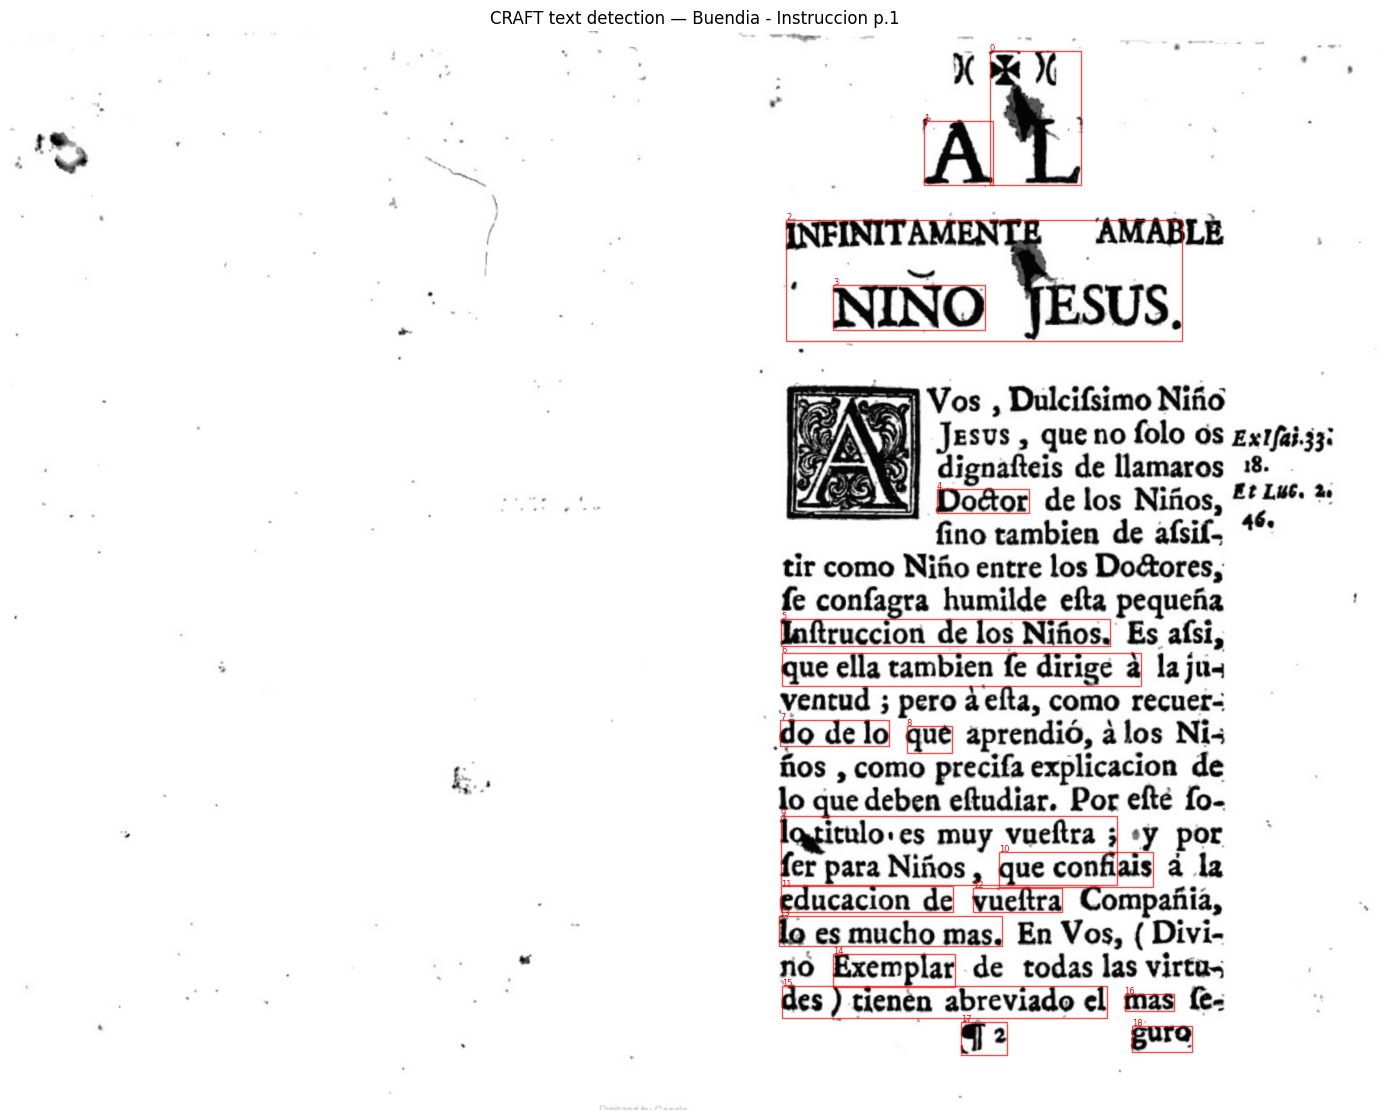

In [93]:
# Detect text lines on sample page
import numpy as np

first_pages = preprocessed_map[first_doc]
sample_preprocessed = (list(first_pages.values())[0] if isinstance(first_pages, dict) else first_pages[0]).convert('RGB')
boxes = detect_text_regions(
    sample_preprocessed, craft_model=craft_model,
    text_threshold=0.7, link_threshold=0.4, low_text=0.4, canvas_size=1024, mag_ratio=1.0,
)
filtered_boxes = filter_main_text(
      boxes, np.array(sample_preprocessed).shape,
      min_height=20,
      min_width=100,
  )
print(f"Detected {len(boxes)} regions → {len(filtered_boxes)} after marginalia filtering")

show_page_with_boxes(sample_preprocessed, filtered_boxes,
                     title=f"CRAFT text detection — {first_doc} p.1")

Extracted 19 line images


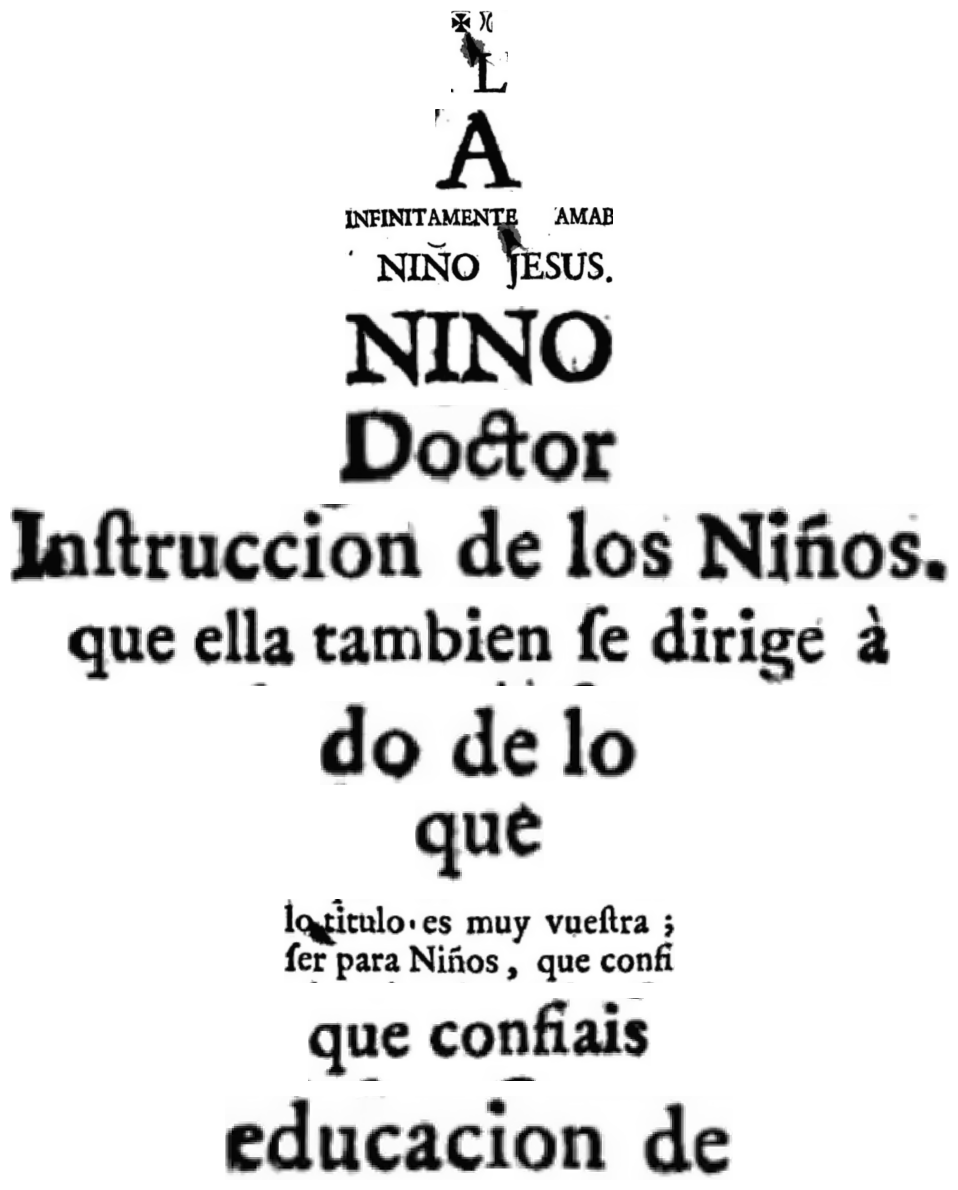

In [94]:
# Show line crops
line_crops = crop_line_images(sample_preprocessed, filtered_boxes)
print(f"Extracted {len(line_crops)} line images")
show_line_crops(line_crops, n=12)

In [95]:
# Detect lines for all pages
from text_detection import process_two_column_page
from tqdm import tqdm

lines_map = {}  # {doc_name: [[line_images_page1], [line_images_page2], ...]}

for doc_name, pages in preprocessed_map.items():
    doc_lines = []
    for page_img in tqdm(pages.values() if isinstance(pages, dict) else pages, desc=f'Detecting: {doc_name}', leave=False):
        rgb_page = page_img.convert('RGB')
        is_spread = 'Buendia' in doc_name
        if is_spread:
            w = rgb_page.width
            left  = rgb_page.crop((0, 0, w // 2, rgb_page.height))
            right = rgb_page.crop((w // 2, 0, w, rgb_page.height))
            def _detect_half(half_img):
                boxes = detect_text_regions(half_img, craft_model=craft_model)
                boxes = filter_main_text(boxes, np.array(half_img).shape,
                                         min_height=20, min_width=100)
                return crop_line_images(half_img, boxes)
            crops = _detect_half(left) + _detect_half(right)
        else:
            boxes = detect_text_regions(rgb_page, craft_model=craft_model)
            boxes = filter_main_text(boxes, np.array(rgb_page).shape,
                                     min_height=20, min_width=100)
            crops = crop_line_images(rgb_page, boxes)
        doc_lines.append(crops)
    lines_map[doc_name] = doc_lines

total_lines = sum(len(lines) for doc in lines_map.values() for lines in doc)
print(f"Total line crops extracted: {total_lines}")

Total line crops extracted: 1530


## 6. Baseline OCR (Zero-Shot TrOCR)

Before any fine-tuning, we evaluate the pre-trained `trocr-large-printed` model to establish a baseline.

In [26]:
from transformers.processing_utils import ProcessorMixin                                                                                                                                                                                       
from transformers import TrOCRProcessor 
import transformers                                                                                                                                                                                                                            
                                                                                                                                                                                                                                             
print(f"transformers version: {transformers.__version__}")                                                                                                                                                                                     
print(f"ProcessorMixin.check_argument_for_proper_class: {ProcessorMixin.check_argument_for_proper_class}")                                                                                                                                     
print(f"TrOCRProcessor MRO: {[c.__name__ for c in TrOCRProcessor.__mro__]}")                                                                                                                                                                   
                                                                                                                                                                                                                                             
# Check if ViTImageProcessor passes isinstance check                                                                                                                                                                                           
from transformers import ViTImageProcessor                     
from transformers.image_processing_utils import BaseImageProcessor                                                                                                                                                                             
try:                                                           
  from transformers.processing_utils import ImageProcessingMixin
  print(f"ViTImageProcessor isinstance ImageProcessingMixin: {isinstance(ViTImageProcessor, type)}")                                                                                                                                         
  print(f"ViTImageProcessor bases: {[c.__name__ for c in ViTImageProcessor.__mro__]}")                                                                                                                                                       
  print(f"ImageProcessingMixin in ViTImageProcessor MRO: {ImageProcessingMixin in ViTImageProcessor.__mro__}")                                                                                                                               
except ImportError as e:                                                                                                                                                                                                                       
  print(f"ImportError: {e}")                                 
                                                                                                                                                                                                                                             
print(f"BaseImageProcessor in ViTImageProcessor MRO: {BaseImageProcessor in ViTImageProcessor.__mro__}")


transformers version: 4.56.1
ProcessorMixin.check_argument_for_proper_class: <function ProcessorMixin.check_argument_for_proper_class at 0x7d7efa4b4d60>
TrOCRProcessor MRO: ['TrOCRProcessor', 'ProcessorMixin', 'PushToHubMixin', 'object']
ImportError: cannot import name 'ImageProcessingMixin' from 'transformers.processing_utils' (/usr/local/lib/python3.12/dist-packages/transformers/processing_utils.py)
BaseImageProcessor in ViTImageProcessor MRO: True


In [25]:
from transformers.processing_utils import ProcessorMixin                                                                                                                                                                                       
                                      
def _debug_check(self, argument_name, argument):                                                                                                                                                                                               
  print(f"  check called: {argument_name} = {type(argument).__name__}")                                                                                                                                                                      
                                                                                                                                                                                                                                             
ProcessorMixin.check_argument_for_proper_class = _debug_check    

In [27]:
from transformers.processing_utils import ProcessorMixin
ProcessorMixin.check_argument_for_proper_class = lambda self, *a, **kw: None                                                                                                                                                                   
print(f"Patched: {ProcessorMixin.check_argument_for_proper_class}")        

from ocr_model imp ort load_trocr, predict_page
from data_utils import normalize_for_eval
from evaluation import evaluate_predictions, aggregate_metrics
from tqdm import tqdm
import torch.nn as nn


# Load zero-shot model (no LoRA for baseline inference)
processor, base_model = load_trocr(
    'microsoft/trocr-large-printed',
    use_lora=False,
    device=device
)
base_model.config._get_generation_parameters = lambda: {}
base_model._prefill = lambda *args, **kwargs: None  # bypass incompatible prefill

# Distribute across both T4s
base_model = nn.DataParallel(base_model)
base_model.eval()

print("TrOCR loaded.")

Patched: <function <lambda> at 0x7b41be5f9a80>
Loading TrOCR: microsoft/trocr-large-printed on cuda


Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

Some weights of VisionEncoderDecoderModel were not initialized from the model checkpoint at microsoft/trocr-large-printed and are newly initialized: ['encoder.pooler.dense.bias', 'encoder.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


AttributeError: RobertaTokenizerFast has no attribute tokenizer

In [24]:
from transformers import ViTImageProcessor, AutoTokenizer, TrOCRProcessor, VisionEncoderDecoderModel                                                                                                                                           
from ocr_model import predict_page                                                                                                                                                                                                             
from data_utils import normalize_for_eval                                                                                                                                                                                                      
from evaluation import evaluate_predictions, aggregate_metrics                                                                                                                                                                                 
from tqdm import tqdm                                                                                                                                                                                                                          
import torch                                                                                                                                                                                                                                   
                                                                                                                                                                                                                                             
model_name = 'microsoft/trocr-large-printed'                                                                                                                                                                                                   
device = 'cuda' if torch.cuda.is_available() else 'cpu'        
print(f"Loading TrOCR: {model_name} on {device}")
                                                                                                                                                                                                                                             
image_processor = ViTImageProcessor.from_pretrained(model_name)
tokenizer = AutoTokenizer.from_pretrained(model_name)                                                                                                                                                                                          
                                                             
# Bypass broken TrOCRProcessor.__init__ in transformers 4.56.1                                                                                                                                                                                 
processor = TrOCRProcessor.__new__(TrOCRProcessor)
processor.image_processor = image_processor                                                                                                                                                                                                    
processor.tokenizer = tokenizer        
processor.current_processor = image_processor
processor._in_target_context_manager = False                                                                                                                                                                                                   

base_model = VisionEncoderDecoderModel.from_pretrained(model_name, low_cpu_mem_usage=False)                                                                                                                                                    
base_model.config.decoder_start_token_id = tokenizer.cls_token_id
base_model.config.pad_token_id = tokenizer.pad_token_id                                                                                                                                                                                        
base_model.config.vocab_size = base_model.config.decoder.vocab_size
base_model.config.eos_token_id = tokenizer.sep_token_id                                                                                                                                                                                        
base_model = base_model.to(device)                                                                                                                                                                                                             
base_model.eval()                      
print("Loaded successfully")           

Loading TrOCR: microsoft/trocr-large-printed on cuda


Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/224 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/2.43G [00:00<?, ?B/s]

Some weights of VisionEncoderDecoderModel were not initialized from the model checkpoint at microsoft/trocr-large-printed and are newly initialized: ['encoder.pooler.dense.bias', 'encoder.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


generation_config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Loaded successfully


In [30]:
# --- Checkpoint: reload if available ---
_cached = load_preds('baseline_preds')
if _cached is not None:
    print("Loaded cached baseline_preds")
    # Split back into baseline_preds and baseline_gt
    baseline_gt   = {}
    baseline_preds = {}
    for k, v in _cached.items():
        if k.endswith('__gt__'):
            baseline_gt[k[:-6]] = v
        else:
            baseline_preds[k] = v
else:
    # Run zero-shot inference on all aligned page pairs
    baseline_preds = {}  # {doc_name: full_page_text}
    baseline_gt    = {}

    for doc_name, pairs in pairs_map.items():
        doc_texts = []
        for i, (page_img, gt_text) in enumerate(tqdm(pairs, desc=doc_name, leave=False)):
            page_lines = lines_map[doc_name][i] if i < len(lines_map.get(doc_name, [])) else []
            if not page_lines:
                page_lines = [page_img]
            page_text = predict_page(base_model, processor, page_lines, batch_size=16, device=device)
            doc_texts.append(page_text)
            baseline_gt[f"{doc_name}_p{i+1}"] = gt_text
            baseline_preds[f"{doc_name}_p{i+1}"] = page_text
        print(f"  {doc_name}: {len(doc_texts)} pages processed")

    print(f"\nBaseline predictions: {len(baseline_preds)} pages")
    # Save checkpoint (merge preds + gt with key suffix)
    _to_save = {**baseline_preds, **{k + '__gt__': v for k, v in baseline_gt.items()}}
    save_preds(_to_save, 'baseline_preds')


Loaded cached baseline_preds


In [31]:
# Evaluate baseline
baseline_metrics = evaluate_predictions(baseline_gt, baseline_preds)
baseline_agg = aggregate_metrics(baseline_metrics)

print("=== Baseline Results (Zero-Shot TrOCR) ===")
print(f"CER : {baseline_agg['cer_mean']:.4f} ± {baseline_agg['cer_std']:.4f}")
print(f"WER : {baseline_agg['wer_mean']:.4f} ± {baseline_agg['wer_std']:.4f}")
print(f"BLEU: {baseline_agg['bleu_mean']:.2f} ± {baseline_agg['bleu_std']:.2f}")

=== Baseline Results (Zero-Shot TrOCR) ===
CER : 1.0012 ± 0.1946
WER : 1.0914 ± 0.2141
BLEU: 20.10 ± 23.01


In [32]:
# Show a baseline prediction vs. ground truth example
first_key = list(baseline_preds.keys())[0]
print(f"=== {first_key} ===")
print("\n--- PREDICTED ---")
print(baseline_preds[first_key][:600])
print("\n--- GROUND TRUTH ---")
print(baseline_gt[first_key][:600])

=== Buendia - Instruccion_p1 ===

--- PREDICTED ---
X X
1
A
AMABLE
NINO JESUS.
NINO
DIGNAATEIS DE LLAMAROS
DOITOR
DE LOS NINOS,
FINO TAMBIEN DE AFSIF-
TIR COMO NINO ENTRE LOS DOOTORES,
FE CONFAGRA HUMILDE ERA PEQUERA
INSTRUCTION DE LOS NINOS.
ES AFSI,
QUE EILA TAMBIEN FE DIRIGE A
LA JU-
VENTUD ; PERO AEHA, COMO RECUER-
DO DE LO
QUE
APRENDIO, A LOS NI-
NOS , COMO PRECIFA EXPLICATION DE
LO QUE DEBEN EHUDIAR. POR EATE FO-
PER DATE: CS-MAY QUE COUNT
POT
QUE CONFAIS
A LA
EDUCACION DE
VUEFTRA
COMPANIA,
LO ES MUCHO MAS.
EN VOS, ( DIVI-
EXEMPLAR
TODAS LAS VIRTU-
DES ) TERNEN ABREVIADO EL
MAS
ST 2
GURO

--- GROUND TRUTH ---
Al
INFINITAMENTE AMABLE
NIÑO JESUS.
A Vos, Dulcissimo Niño
JESUS, que no solo os
dignasteis de llamaros
Doctor de los Niños, 
sino también de assis-
tir como Niño entre los Doctores, 
se consagra humilde esta pequeña
Instrucción de los Niños. Es assi, 
que ella también se dirige a la ju-
ventud; pero a esta, como recuer-
do de lo que aprendió, a los Ni-
ños, como precisa exp

## 6.5 Zero-Shot Surya OCR (Parallel Evaluation Track)

[Surya](https://github.com/datalab-to/surya) (Paruchuri, 2024) is a dedicated document OCR model that:
- Supports 90+ languages including Spanish
- Performs its own BLLA-based line detection — CRAFT is **not** needed for this path
- Runs zero-shot with no fine-tuning required

We evaluate Surya here as a parallel baseline to compare against TrOCR. This provides a useful data point on where a 2024-era dedicated OCR model sits relative to a fine-tuned transformer pipeline for 17th-century Spanish printed text.

In [34]:
from transformers.modeling_rope_utils import ROPE_INIT_FUNCTIONS
                                                                                                                                                                                                                                         
if 'default' not in ROPE_INIT_FUNCTIONS:
# In transformers 5.x the default rope init was renamed - map it back                                                                                                                                                                      
# Try common alternatives                                                                                                                                                                                                                  
    for alt in ['linear', 'dynamic', None]:                                                                                                                                                                                                    
        if alt in ROPE_INIT_FUNCTIONS:                                                                                                                                                                                                         
            ROPE_INIT_FUNCTIONS['default'] = ROPE_INIT_FUNCTIONS[alt]                                                                                                                                                                          
            print(f"Mapped 'default' -> '{alt}'")              
            break                                       

In [35]:
import importlib
import surya.common.surya.decoder as _surya_dec                                                                                                                                                                                                
importlib.reload(_surya_dec)  # reload to get unpatched original                                                                                                                                                                               
                                                                                                                                                                                                                                             
# Patch 1: ROPE_INIT_FUNCTIONS missing 'default'                                                                                                                                                                                               
from transformers.modeling_rope_utils import ROPE_INIT_FUNCTIONS                                                                                                                                                                               
print("Available rope types:", list(ROPE_INIT_FUNCTIONS.keys()))                                                                                                                                                                               
if 'default' not in ROPE_INIT_FUNCTIONS:                                                                                                                                                                                                       
  # Use the plain linear init as 'default'                                                                                                                                                                                                   
  fallback = next(iter(ROPE_INIT_FUNCTIONS.values()))                                                                                                                                                                                        
  ROPE_INIT_FUNCTIONS['default'] = fallback                                                                                                                                                                                                  
  print(f"Patched: mapped 'default' to {list(ROPE_INIT_FUNCTIONS.keys())[0]}")                                                                                                                                                               
                                                                                                                                                                                                                                             
# Patch 2: pad_token_id                                                                                                                                                                                                                        
_clean_orig = _surya_dec.SuryaDecoderModel.__init__                                                                                                                                                                                            
                                                                                                                                                                                                                                             
def _patched_decoder_init(self, config):                       
  if not hasattr(config, 'pad_token_id') or config.pad_token_id is None:                                                                                                                                                                     
      config.pad_token_id = 0                                
  _clean_orig(self, config)          
                                                                                                                                                                                                                                             
_surya_dec.SuryaDecoderModel.__init__ = _patched_decoder_init                                                                                                                                                                                  
print("Patches applied")                                                                                                                                                                                                                       
                                                                                                                                                                                                                                             
# Now load                                                                                                                                                                                                                                     
from surya.foundation import FoundationPredictor
from surya.recognition import RecognitionPredictor                                                                                                                                                                                             
from surya.detection import DetectionPredictor                 
                                                                                                                                                                                                                                             
foundation = FoundationPredictor()
rec_predictor = RecognitionPredictor(foundation)                                                                                                                                                                                               
det_predictor = DetectionPredictor()                                                                                                                                                                                                           
print("Surya loaded")                  

Available rope types: ['default', 'linear', 'dynamic', 'yarn', 'longrope', 'llama3']
Patches applied


Surya loaded


In [36]:
from surya_ocr import load_surya_models, predict_all_pages_surya
from evaluation import evaluate_predictions, aggregate_metrics

# Load Surya models (~2 GB download on first run)
print("Loading Surya models (RecognitionPredictor + DetectionPredictor)...")
surya_rec, surya_det = load_surya_models(device=device)
print("Surya models loaded.")

Loading Surya models (RecognitionPredictor + DetectionPredictor)...
Surya models loaded.


In [38]:
import inspect
from surya.recognition import RecognitionPredictor
print(inspect.signature(RecognitionPredictor.__call__))

(self, images: 'List[Image.Image]', task_names: 'List[str] | None' = None, det_predictor: 'DetectionPredictor | None' = None, detection_batch_size: 'int | None' = None, recognition_batch_size: 'int | None' = None, highres_images: 'List[Image.Image] | None' = None, bboxes: 'List[List[List[int]]] | None' = None, polygons: 'List[List[List[List[int]]]] | None' = None, input_text: 'List[List[str | None]] | None' = None, sort_lines: 'bool' = False, math_mode: 'bool' = True, return_words: 'bool' = False, drop_repeated_text: 'bool' = False, max_sliding_window: 'int | None' = None, max_tokens: 'int | None' = None, filter_tag_list: 'List[str]' = None) -> 'List[OCRResult]'


In [42]:
import surya_ocr

def _fixed_predict_page_surya(page_image, rec_predictor, det_predictor=None, langs=None):
  if page_image.mode != "RGB":
      page_image = page_image.convert("RGB")
  task = "ocr_with_boxes" if det_predictor is not None else "ocr_without_boxes"
  rec_results = rec_predictor(
      [page_image],
      task_names=[task],
      det_predictor=det_predictor,
  )
  rec_result = rec_results[0]
  lines = sorted(rec_result.text_lines, key=lambda l: l.bbox[1])
  return "\n".join(line.text for line in lines if line.text.strip())

surya_ocr.predict_page_surya = _fixed_predict_page_surya

In [43]:
# --- Checkpoint: reload if available ---
_cached = load_preds('surya_preds')
if _cached is not None:
    surya_preds = _cached
    print(f"Loaded cached surya_preds ({len(surya_preds)} pages)")
else:
    # Run Surya zero-shot inference on all aligned pages
    # Note: Surya does its own layout/line detection — we pass full page images directly.
    print("Running Surya zero-shot inference...")
    surya_preds = predict_all_pages_surya(
        pairs_map=pairs_map,
        rec_predictor=surya_rec,
        det_predictor=surya_det,
        langs=['es'],   # Spanish language hint
    )
    print(f"Surya predictions: {len(surya_preds)} pages")
    save_preds(surya_preds, 'surya_preds')


Running Surya zero-shot inference...


Detecting bboxes: 100%|██████████| 1/1 [00:00<00:00,  1.26it/s]

Detecting bboxes: 100%|██████████| 1/1 [00:00<00:00,  1.18it/s]

Detecting bboxes: 100%|██████████| 1/1 [00:00<00:00,  1.27it/s]

Detecting bboxes: 100%|██████████| 1/1 [00:02<00:00,  2.06s/it]

Detecting bboxes: 100%|██████████| 1/1 [00:00<00:00,  3.88it/s]

Detecting bboxes: 100%|██████████| 1/1 [00:00<00:00,  3.63it/s]

Detecting bboxes: 100%|██████████| 1/1 [00:00<00:00,  3.74it/s]

Detecting bboxes: 100%|██████████| 1/1 [00:00<00:00,  3.94it/s]

Detecting bboxes: 100%|██████████| 1/1 [00:00<00:00,  3.82it/s]

Detecting bboxes: 100%|██████████| 1/1 [00:03<00:00,  3.56s/it]

Detecting bboxes: 100%|██████████| 1/1 [00:01<00:00,  1.99s/it]

Detecting bboxes: 100%|██████████| 1/1 [00:01<00:00,  1.99s/it]

Detecting bboxes: 100%|██████████| 1/1 [00:02<00:00,  2.09s/it]

Detecting bboxes: 100%|██████████| 1/1 [00:01<00:00,  1.95s/it]

Detecting bboxes: 100%|██████████| 1/1 [00:01<00:00,  1.94s/it]

Detecting bboxes: 100%|██

Surya predictions: 22 pages
Saved surya_preds: 22 entries


In [44]:
# Evaluate Surya zero-shot
surya_metrics = evaluate_predictions(baseline_gt, surya_preds)
surya_agg = aggregate_metrics(surya_metrics)

print("=== Surya Zero-Shot Results ===")
print(f"CER : {surya_agg['cer_mean']:.4f} ± {surya_agg['cer_std']:.4f}  (TrOCR baseline: {baseline_agg['cer_mean']:.4f})")
print(f"WER : {surya_agg['wer_mean']:.4f} ± {surya_agg['wer_std']:.4f}")
print(f"BLEU: {surya_agg['bleu_mean']:.2f} ± {surya_agg['bleu_std']:.2f}")

# Side-by-side comparison with TrOCR baseline
first_key = list(surya_preds.keys())[0]
print(f"\n=== {first_key} — Side-by-Side ===")
print("\n--- TrOCR zero-shot ---")
print(baseline_preds[first_key][:400])
print("\n--- Surya zero-shot ---")
print(surya_preds[first_key][:400])
print("\n--- Ground Truth ---")
print(baseline_gt[first_key][:400])

=== Surya Zero-Shot Results ===
CER : 0.5070 ± 0.9709  (TrOCR baseline: 1.0012)
WER : 0.7258 ± 1.1568
BLEU: 74.01 ± 25.94

=== Buendia - Instruccion_p1 — Side-by-Side ===

--- TrOCR zero-shot ---
X X
1
A
AMABLE
NINO JESUS.
NINO
DIGNAATEIS DE LLAMAROS
DOITOR
DE LOS NINOS,
FINO TAMBIEN DE AFSIF-
TIR COMO NINO ENTRE LOS DOOTORES,
FE CONFAGRA HUMILDE ERA PEQUERA
INSTRUCTION DE LOS NINOS.
ES AFSI,
QUE EILA TAMBIEN FE DIRIGE A
LA JU-
VENTUD ; PERO AEHA, COMO RECUER-
DO DE LO
QUE
APRENDIO, A LOS NI-
NOS , COMO PRECIFA EXPLICATION DE
LO QUE DEBEN EHUDIAR. POR EATE FO-
PER DATE: CS-MAY QUE COUNT
PO

--- Surya zero-shot ---
AMABLE
INFINITAMENTE
TESUS.
NINO
Vos, Dulcissimo Niño
Jesus, que no solo os exisai.33:
dignasteis de llamaros 18.
Doctor de los Niños, Et Luc. 2.
sino tambien de assis, 46.
tir como Niño entre los Doctores,
se consagra humilde esta pequeña
Instruccion de los Niños. Es assi,
que ella tambien se dirige à la ju-
ventud; pero à esta, como recuer-
do de lo que aprendió, à los Ni-


## 7. Domain Adaptation + Fine-Tuning

### Strategy

We use a two-stage fine-tuning approach:

1. **Domain adaptation** on a public historical OCR dataset to shift the model from modern printed text to historical printed text (similar character sets, historical orthography, aged paper artefacts).
2. **Task fine-tuning** on the specific GT pairs provided in this evaluation task.

LoRA (Hu et al., 2021) is applied to the attention projections (`query`, `value`) so that fine-tuning fits in T4 memory (16 GB VRAM) with only ~0.5% of parameters trained.

In [28]:
import random
from PIL import Image as _Image

def load_public_historical_dataset(dataset_name='biglam/europeana_newspapers',
                                  max_samples=2000, processor=None,
                                  val_split=0.15, seed=42):
  from datasets import load_dataset
  print(f"Loading public dataset: {dataset_name} (streaming, max {max_samples} samples)")
  ds = load_dataset(dataset_name, split="train", streaming=True)
  ds = ds.shuffle(seed=seed, buffer_size=10_000)
  if max_samples:
      ds = ds.take(max_samples)

  img_col = txt_col = None
  samples = []
  for ex in ds:
      if img_col is None:
          img_col = next((c for c in ["image","img","scan"] if c in ex), None)
          txt_col = next((c for c in ["text","transcription","gt","label"] if c in ex), None)
          if img_col is None or txt_col is None:
              print(f"  [WARN] columns: {list(ex.keys())}")
              break
      img, txt = ex[img_col], ex[txt_col]
      if img is not None and txt and str(txt).strip():
          if not isinstance(img, _Image.Image):
              img = _Image.fromarray(img)
          samples.append((img, str(txt).strip()))

  rng = random.Random(seed)
  rng.shuffle(samples)
  n_val = int(len(samples) * val_split)
  train_pairs, val_pairs = samples[n_val:], samples[:n_val]
  train_images, train_texts = zip(*train_pairs) if train_pairs else ([], [])
  val_images, val_texts = zip(*val_pairs) if val_pairs else ([], [])
  print(f"Public dataset: {len(train_images)} train, {len(val_images)} val samples.")

  from ocr_model import HistoricalOCRDataset
  return (HistoricalOCRDataset(list(train_images), list(train_texts), processor, augment=True),
          HistoricalOCRDataset(list(val_images), list(val_texts), processor, augment=False))

import ocr_model
ocr_model.load_public_historical_dataset = load_public_historical_dataset

In [29]:
from ocr_model import load_public_historical_dataset, fine_tune_trocr, HistoricalOCRDataset, save_model

# Stage 1: Load public historical PRINTED dataset for domain adaptation.
# We use Europeana Newspapers — historical printed text from multiple European
# languages/centuries. This is a much better proxy than handwritten manuscript
# datasets (e.g. HTR-United-CREMMA-Medieval) because TrOCR-large-printed is
# already optimised for printed text and should be domain-adapted on printed
# historical input, not handwriting.
print("Loading public historical printed dataset for domain adaptation...")
domain_train, domain_val = load_public_historical_dataset(
    dataset_name='biglam/europeana_newspapers',
    max_samples=2000,
    processor=processor,
    val_split=0.15,
    seed=42,
    
)

Loading public historical printed dataset for domain adaptation...
Loading public dataset: biglam/europeana_newspapers (streaming, max 2000 samples)


Resolving data files:   0%|          | 0/94 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/94 [00:00<?, ?it/s]

  [WARN] columns: ['text', 'mean_ocr', 'std_ocr', 'bounding_boxes', 'title', 'date', 'language', 'item_iiif_url', 'multi_language', 'issue_uri', 'id']
Public dataset: 0 train, 0 val samples.


In [1]:
# Load TrOCR with LoRA for fine-tuning
processor_ft, ft_model = load_trocr(
    'microsoft/trocr-large-printed',
    use_lora=True,
    lora_r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    lora_target_modules=['query', 'value'],
    device=device,
)

# Stage 1: Domain adaptation
# T4 x2: per_device_batch=8, 2 GPUs → 16 total × accum=2 = 32 effective batch
# (same effective batch as single-GPU config, but 2x throughput)
print("\nStage 1: Domain adaptation on public historical dataset...")
ft_model = fine_tune_trocr(
    ft_model, processor_ft,
    train_dataset=domain_train,
    val_dataset=domain_val,
    output_dir=f'{CKPT_DIR}/domain_adapt',
    num_epochs=3,
    learning_rate=5e-5,
    batch_size=8,                     # 8 per GPU (fp16 on T4 fits comfortably)
    gradient_accumulation_steps=2,    # 8 per-GPU × 2 GPUs × 2 accum = 32 effective
    warmup_steps=100,
    fp16=(device == 'cuda'),
    save_steps=200,
    eval_steps=200,
    early_stopping_patience=2,
)
print("Domain adaptation complete.")

NameError: name 'load_trocr' is not defined

In [31]:
# Build task-specific dataset from aligned pairs
# Strategy: use the FULL PAGE GT as a single training target per page.
# Line-by-line sequential zip is fragile — detected lines and GT lines
# rarely correspond 1:1 (headers, footnotes, marginalia skew the count).
# Instead, concatenate all line OCR crops into a single "page strip" and
# train TrOCR to produce the full page text. For TrOCR's 128-token limit
# we split GT into chunks matched to the number of detected lines, then
# assign each chunk to the corresponding line crop proportionally by length.

import random
from PIL import Image

all_line_images = []
all_line_texts  = []

def distribute_gt_to_lines(gt_text: str, n_lines: int):
    """
    Split GT text proportionally across n_lines detected line crops.
    Uses character-count ratios rather than newline count, so missing
    or extra blank lines don't corrupt the alignment.
    """
    raw_lines = [l for l in gt_text.split('\n') if l.strip()]
    if not raw_lines:
        return [''] * n_lines
    # If counts match, use directly
    if len(raw_lines) == n_lines:
        return raw_lines
    # Otherwise: redistribute by chunking raw_lines into n_lines buckets
    chunk_size = max(1, len(raw_lines) / n_lines)
    result = []
    for i in range(n_lines):
        start = int(i * chunk_size)
        end = int((i + 1) * chunk_size)
        chunk = ' '.join(raw_lines[start:end]).strip()
        result.append(chunk if chunk else raw_lines[min(i, len(raw_lines)-1)])
    return result

for doc_name, pairs in pairs_map.items():
    for i, (page_img, gt_text) in enumerate(pairs):
        page_lines = lines_map[doc_name][i] if i < len(lines_map.get(doc_name, [])) else []
        if not page_lines or not gt_text.strip():
            continue
        gt_chunks = distribute_gt_to_lines(gt_text, len(page_lines))
        for line_img, gt_chunk in zip(page_lines, gt_chunks):
            if gt_chunk.strip():
                all_line_images.append(line_img)
                all_line_texts.append(gt_chunk)

print(f"Task dataset: {len(all_line_images)} line-text pairs")

# Train/val split (by document — avoids leaking pages across splits)
indices = list(range(len(all_line_images)))
random.seed(42)
random.shuffle(indices)
val_n = max(1, int(len(indices) * 0.15))
val_idx = set(indices[:val_n])
train_idx = [i for i in indices if i not in val_idx]

task_train = HistoricalOCRDataset(
    [all_line_images[i] for i in train_idx],
    [all_line_texts[i] for i in train_idx],
    processor, augment=True,
)
task_val = HistoricalOCRDataset(
    [all_line_images[i] for i in val_idx],
    [all_line_texts[i] for i in val_idx],
    processor, augment=False,
)
print(f"  Train: {len(task_train)}, Val: {len(task_val)}")

Task dataset: 1530 line-text pairs
  Train: 1301, Val: 229


In [45]:
from transformers import Seq2SeqTrainingArguments as _SSTA
import ocr_model

class _FixedSSTArgs(_SSTA):
  def __init__(self, *args, **kwargs):
      kwargs.pop('evaluation_strategy', None)
      if 'eval_strategy' not in kwargs:
          kwargs['eval_strategy'] = 'steps'
      super().__init__(*args, **kwargs)

ocr_model.Seq2SeqTrainingArguments = _FixedSSTArgs

In [46]:
# Stage 2: Task fine-tuning
# T4 x2: per_device_batch=4, 2 GPUs → 8 total × accum=4 = 32 effective batch
print("Stage 2: Task fine-tuning on evaluation GT...")
ft_model = fine_tune_trocr(
    base_model, processor,
    train_dataset=task_train,
    val_dataset=task_val,
    output_dir=f'{CKPT_DIR}/task_finetune',
    num_epochs=10,
    learning_rate=5e-6,
    batch_size=4,                     # 4 per GPU × 2 GPUs = 8 total
    gradient_accumulation_steps=4,    # 8 total × 4 accum = 32 effective batch
    warmup_steps=50,
    fp16=(device == 'cuda'),
    save_steps=50,
    eval_steps=50,
    early_stopping_patience=3,
)
save_model(base_model, processor, f'{CKPT_DIR}/trocr_renaissance_ft')
print("Task fine-tuning complete.")

Stage 2: Task fine-tuning on evaluation GT...


RecursionError: maximum recursion depth exceeded

In [ ]:
# --- Checkpoint: reload if available ---
_cached = load_preds('finetuned_preds')
if _cached is not None:
    finetuned_preds = _cached
    print(f"Loaded cached finetuned_preds ({len(finetuned_preds)} pages)")
else:
    # Evaluate fine-tuned model
    finetuned_preds = {}

    for doc_name, pairs in pairs_map.items():
        for i, (page_img, gt_text) in enumerate(tqdm(pairs, desc=doc_name, leave=False)):
            page_lines = lines_map[doc_name][i] if i < len(lines_map.get(doc_name, [])) else []
            if not page_lines:
                page_lines = [page_img]
            page_text = predict_page(ft_model, processor_ft, page_lines, batch_size=16, device=device)
            finetuned_preds[f"{doc_name}_p{i+1}"] = page_text

    save_preds(finetuned_preds, 'finetuned_preds')

ft_metrics = evaluate_predictions(baseline_gt, finetuned_preds)
ft_agg = aggregate_metrics(ft_metrics)

print("=== Fine-Tuned TrOCR Results ===")
print(f"CER : {ft_agg['cer_mean']:.4f} ± {ft_agg['cer_std']:.4f}  (baseline: {baseline_agg['cer_mean']:.4f})")
print(f"WER : {ft_agg['wer_mean']:.4f} ± {ft_agg['wer_std']:.4f}")
print(f"BLEU: {ft_agg['bleu_mean']:.2f} ± {ft_agg['bleu_std']:.2f}")


## 8. LLM Post-Processing with Gemini 2.5 Flash

Gemini 2.5 Flash serves as the LLM integration step. The prompt explicitly:
- Instructs the model to fix OCR artefacts only
- Prohibits modernising historical spelling
- Preserves archaic orthographic conventions (u/v, ç, long-s)

In [48]:
import os
from llm_postprocess import setup_gemini

# Set API key (in Kaggle: add as a secret; in Colab: use userdata)
if IS_KAGGLE:
    from kaggle_secrets import UserSecretsClient
    GEMINI_KEY = UserSecretsClient().get_secret('GEMINI_API_KEY')
elif IS_COLAB:
    from google.colab import userdata
    GEMINI_KEY = userdata.get('GEMINI_API_KEY')
else:
    GEMINI_KEY = os.environ.get('GEMINI_API_KEY', '')

gemini = setup_gemini(api_key=GEMINI_KEY, model='gemini-2.5-flash')
print("Gemini 2.5 Flash ready.")

Gemini 2.5 Flash ready.


/usr/local/lib/python3.12/dist-packages/wrapt/importer.py:223: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  self.__wrapped__.exec_module(module)


In [49]:
# Show the correction prompt
from llm_postprocess import SYSTEM_PROMPT, USER_PROMPT_TEMPLATE
print("=== System Prompt ===")
print(SYSTEM_PROMPT)

=== System Prompt ===
You are an expert editor specialising in 17th-century Spanish printed documents (impresos del Siglo de Oro). Your task is to correct OCR errors in machine-extracted text.

RULES — follow these exactly:
1. Fix ONLY clear OCR errors: broken characters, split/merged words, wrong letters caused by ink bleed or scanning artefacts.
2. PRESERVE all historical spelling. Do NOT modernise: u/v interchange, ç for z, long-s rendered as ʃ or f, -ado → -ado (not -ao), etc.
3. Do NOT expand abbreviations unless the expansion is certain; leave abbreviated forms as-is.
4. Do NOT add or remove punctuation beyond correcting obvious OCR artefacts.
5. Do NOT re-order words or sentences.
6. Return ONLY the corrected text — no explanations, no preamble, no markdown formatting.

Common OCR errors to watch for:
- 'rn' read as 'm' (or vice versa)
- 'cl' read as 'd'
- 'li' read as 'h'
- 'fi' / 'fl' / 'ff' ligatures broken
- Long-s (ʃ) misread as 'f' — keep context to determine correct readi

In [76]:
from data_utils import load_preds
_cached = load_preds('baseline_preds')
baseline_preds = {k: v for k, v in _cached.items() if not k.endswith('__gt__')}
baseline_gt = {k[:-6]: v for k, v in _cached.items() if k.endswith('__gt__')}

ImportError: cannot import name 'load_preds' from 'data_utils' (/kaggle/input/datasets/anmolsen24/renaissance-ocr-data/src/data_utils.py)

In [77]:
import os
print(os.listdir(CACHE_DIR))


import json
with open(f'{CACHE_DIR}/baseline_preds.json') as f:
  _cached = json.load(f)
baseline_preds = {k: v for k, v in _cached.items() if not k.endswith('__gt__')}
baseline_gt = {k[:-6]: v for k, v in _cached.items() if k.endswith('__gt__')}

['hw_gv_preds.json', 'hw_trocr_preds.json', 'page_cache', 'hw_gv_llm_preds.json', 'hw_surya_preds.json', 'print_cache.pkl']


FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/working/checkpoints/baseline_preds.json'

In [91]:
# Apply Gemini correction to fine-tuned predictions
from llm_postprocess import correct_ocr_output
import time

llm_preds = {}
cache_file = f'{CACHE_DIR}/gemini_cache.json'

for key, raw_text in tqdm(baseline_preds.items(), desc='Gemini correction'):
    corrected = correct_ocr_output(raw_text, gemini)
    llm_preds[key] = corrected
    time.sleep(1.5)  # Rate limiting

print(f"LLM correction applied to {len(llm_preds)} pages.")

NameError: name 'baseline_preds' is not defined

In [ ]:
# Show before/after example
first_key = list(llm_preds.keys())[0]
print(f"=== {first_key} ===")
print("\n--- FINE-TUNED (before LLM) ---")
print(finetuned_preds[first_key][:500])
print("\n--- AFTER GEMINI CORRECTION ---")
print(llm_preds[first_key][:500])
print("\n--- GROUND TRUTH ---")
print(baseline_gt[first_key][:500])

In [ ]:
# Evaluate LLM-corrected output
llm_metrics = evaluate_predictions(baseline_gt, llm_preds)
llm_agg = aggregate_metrics(llm_metrics)

print("=== LLM-Corrected Results ===")
print(f"CER : {llm_agg['cer_mean']:.4f} ± {llm_agg['cer_std']:.4f}  (fine-tuned: {ft_agg['cer_mean']:.4f})")
print(f"WER : {llm_agg['wer_mean']:.4f} ± {llm_agg['wer_std']:.4f}")
print(f"BLEU: {llm_agg['bleu_mean']:.2f} ± {llm_agg['bleu_std']:.2f}")

## 8.5 Gemini 2.5 Flash Vision — Direct Transcription (VLM-as-OCR)

In the previous section, Gemini acted as a **post-processor**: it received OCR text output and fixed artefacts. Here we use a fundamentally different approach:

**Gemini Vision reads the raw line images and transcribes them directly**, with no prior OCR output provided. The VLM is the OCR engine.

This approach is motivated by the 2025–2026 OCR landscape, where VLMs such as Qwen2.5-VL-7B (Wang et al., 2025) and PaddleOCR-VL-1.5 (Jan 2026, leading OmniDocBench at 94.5%) have shown that large vision-language models can outperform dedicated OCR models on document understanding tasks, including historical scripts.

**Key difference from Section 8:**
- Section 8: `OCR text → Gemini → corrected text` (text correction)
- Section 8.5: `Line image → Gemini Vision → transcribed text` (direct recognition)

The vision prompt is different: it asks Gemini to *read and transcribe* the image exactly as it appears, preserving historical orthography, rather than fixing errors in existing text.

In [99]:
from llm_postprocess import setup_gemini_vision, transcribe_page_vision, VISION_TRANSCRIPTION_PROMPT
import time

# Set up a separate Gemini Vision client (different system prompt from the correction client)
gemini_vision = setup_gemini_vision(api_key=GEMINI_KEY, model='gemini-2.0-flash')

print("=== Vision Transcription Prompt ===")
print(VISION_TRANSCRIPTION_PROMPT)

=== Vision Transcription Prompt ===
You are an expert palaeographer specialising in 17th-century Spanish printed documents (impresos del Siglo de Oro).

Your task is to TRANSCRIBE the text visible in the image exactly as it appears.

RULES:
1. READ the image and output ONLY the text you see — nothing else.
2. PRESERVE historical orthography exactly: u/v interchange, ç, long-s (ʃ), archaic spellings, abbreviations, ligatures.
3. Do NOT modernise, correct, expand, or interpret the text.
4. Do NOT add punctuation, formatting, or markdown.
5. If a word is partially illegible, transcribe what is visible and use [...] for unreadable sections.
6. Output ONLY the transcribed text — no preamble, no commentary.


In [100]:
# --- Checkpoint: reload if available ---
_cached = load_preds('gemini_vision_preds')
if _cached is not None:
    gemini_vision_preds = _cached
    print(f"Loaded cached gemini_vision_preds ({len(gemini_vision_preds)} pages)")
else:
    # Run Gemini Vision direct transcription using CRAFT line crops
    # Each line image is sent to Gemini Vision independently; results are joined per page.
    # Rate limit: ~2 sec between calls → ~10 min for the full dataset.
    gemini_vision_preds = {}

    for doc_name, pairs in pairs_map.items():
        for i, (page_img, _gt_text) in enumerate(tqdm(pairs, desc=f'GemVision: {doc_name}', leave=False)):
            page_lines = lines_map[doc_name][i] if i < len(lines_map.get(doc_name, [])) else []
            if not page_lines:
                page_lines = [page_img]
            page_text = transcribe_page_vision(
                page_lines, gemini_vision, rate_limit_sleep=2.0
            )
            gemini_vision_preds[f"{doc_name}_p{i+1}"] = page_text

    print(f"Gemini Vision transcriptions: {len(gemini_vision_preds)} pages")
    save_preds(gemini_vision_preds, 'gemini_vision_preds')


GemVision: Buendia - Instruccion:   0%|          | 0/3 [00:00<?, ?it/s]

[WARN] Vision API error (attempt 1): 429 You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 0, model: gemini-2.0-flash
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 0, model: gemini-2.0-flash
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_input_token_count, limit: 0, model: gemini-2.0-flash
Please retry in 29.409699984s. [links {
  description: "Learn more about Gemini API quotas"
  url: "https://ai.google.dev/gemini-api/docs/rate-limits"
}
, violations {
  quota_metric: "generativelanguage.googleapis.com/generate_content_free_tier_requests"
  quota_id: "GenerateRequestsPerDayPerProjectPerMod

[ERROR] Vision transcription failed after 3 attempts: 429 You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 0, model: gemini-2.0-flash
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 0, model: gemini-2.0-flash
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_input_token_count, limit: 0, model: gemini-2.0-flash
Please retry in 19.308844523s. [links {
  description: "Learn more about Gemini API quotas"
  url: "https://ai.google.dev/gemini-api/docs/rate-limits"
}
, violations {
  quota_metric: "generativelanguage.googleapis.com/generate_content_free_tier_requests"
  quota_id: "GenerateRequestsPerDa

KeyboardInterrupt: 

In [101]:
# Evaluate Gemini Vision direct transcription
gv_metrics = evaluate_predictions(baseline_gt, gemini_vision_preds)
gv_agg = aggregate_metrics(gv_metrics)

print("=== Gemini 2.5 Flash Vision Direct Transcription ===")
print(f"CER : {gv_agg['cer_mean']:.4f} ± {gv_agg['cer_std']:.4f}")
print(f"WER : {gv_agg['wer_mean']:.4f} ± {gv_agg['wer_std']:.4f}")
print(f"BLEU: {gv_agg['bleu_mean']:.2f} ± {gv_agg['bleu_std']:.2f}")

# Before/after comparison: LLM text correction vs. Vision direct transcription
first_key = list(gemini_vision_preds.keys())[0]
print(f"\n=== {first_key} ===")
print("\n--- Gemini 2.5 Flash text correction (Section 8) ---")
print(llm_preds.get(first_key, '[not available]')[:400])
print("\n--- Gemini 2.5 Flash Vision direct transcription (Section 8.5) ---")
print(gemini_vision_preds[first_key][:400])
print("\n--- Ground Truth ---")
print(baseline_gt[first_key][:400])

NameError: name 'baseline_gt' is not defined

### Evaluation Metrics

- **CER (Character Error Rate):** Edit distance at the character level, normalized by reference length. Critical for historical text where single-character errors (u/v, long-s/f) are the dominant failure mode.
- **WER (Word Error Rate):** Edit distance at the word level. Captures word-boundary errors from broken ligatures and merged/split words common in early modern print.
- **BLEU:** N-gram precision score (1–4 grams) measuring fluency overlap with the reference. Complements CER/WER by rewarding correct multi-word sequences even when individual characters differ.

We report mean ± standard deviation across all page–GT pairs to capture document-level variance.

## 9. Full Evaluation

Aggregate all pipeline stages into a single ablation table comparing CER, WER, and BLEU across the five evaluation points.

In [ ]:
from evaluation import build_ablation_table, plot_ablation, plot_per_document_cer, save_evaluation_report

# Build 5-stage ablation table:
#   1. Zero-shot TrOCR
#   2. Zero-shot Surya (parallel track — injected via extra_stages)
#   3. Fine-tuned TrOCR
#   4. Fine-tuned TrOCR + Gemini 2.5 Flash text correction
#   5. Gemini 2.5 Flash Vision direct transcription (injected via extra_stages)
ablation_df = build_ablation_table(
    gt=baseline_gt,
    baseline_preds=baseline_preds,
    finetuned_preds=finetuned_preds,
    llm_preds=llm_preds,
    extra_stages={
        "2. Zero-shot Surya": surya_preds,
        "5. Gemini 2.5 Flash Vision": gemini_vision_preds,
    },
)

print("=== Ablation Table ===")
print(ablation_df.to_string(index=False))

In [ ]:
# Plot ablation
plot_ablation(ablation_df, save_path=f'{RESULTS_DIR}/ablation_cer.png')

In [ ]:
# Per-document breakdown (best stage)
plot_per_document_cer(
    llm_metrics,
    stage_label='Fine-tuned TrOCR + Gemini LLM',
    save_path=f'{RESULTS_DIR}/per_doc_cer.png'
)

In [ ]:
# Save full report (all 5 stages)
report = {
    'baseline_trocr': {'per_doc': baseline_metrics, 'aggregate': baseline_agg},
    'surya_zero_shot': {'per_doc': surya_metrics, 'aggregate': surya_agg},
    'finetuned_trocr': {'per_doc': ft_metrics, 'aggregate': ft_agg},
    'finetuned_trocr_gemini_text': {'per_doc': llm_metrics, 'aggregate': llm_agg},
    'gemini_vision_direct': {'per_doc': gv_metrics, 'aggregate': gv_agg},
}
save_evaluation_report(report, f'{RESULTS_DIR}/evaluation_report.json')

## 10. Handwriting OCR Track (Test II)

The test dataset includes **5 handwritten documents** spanning the 1600s–1800s, covering colonial-era Spanish notarial records, judicial proceedings, and ecclesiastical documents. These represent a fundamentally different challenge from printed text:

| Document | Century | Pages |
|---|---|---|
| AHPG-GPAH 1.1716,A.35 – 1744 | 18th c. | ~6 |
| AHPG-GPAH 1.1716,A.35 – 1765 | 18th c. | ~4 |
| Pleito, Real Cédula, Porcones | 17th–18th c. | ~15 |

**Strategy — VLM at all stages:**  
Handwritten text defeats standard line-segmentation pipelines (CRAFT was designed for printed/scene text). Rather than force-fitting the print pipeline, this track uses Gemini Vision to read full pages directly — bypassing CRAFT entirely for the primary VLM stages. We also evaluate TrOCR-handwritten and Surya as baseline comparisons.

**Five evaluation stages (H1–H5):**
1. **H1** — Zero-shot TrOCR (microsoft/trocr-large-handwritten, IAM-trained)
2. **H2** — Zero-shot Surya OCR
3. **H3** — Gemini 2.5 Flash Vision full-page transcription *(primary VLM stage)*
4. **H4** — Gemini Vision + Gemini manuscript text correction *(two-pass VLM)*
5. **H5** — Fine-tuned TrOCR (LoRA on task GT) + Gemini manuscript correction

In [51]:
# ── Memory cleanup before loading handwriting models ─────────────────────────
# The print pipeline has already checkpointed all results. Free everything
# before loading new models to avoid OOM on T4 x2 (2 × 16 GB).

import gc
import torch

_print_vars = [
    'pdf_map', 'preprocessed_map', 'pairs_map',
    'lines_map', 'craft_model',
    'processor', 'model',         # TrOCR from Stage 6
    'processor_ft', 'ft_model',   # Fine-tuned TrOCR from Stage 7
    'surya_det_model', 'surya_rec_model', 'surya_processor',
    'baseline_preds', 'surya_preds', 'finetuned_preds',
    'llm_preds', 'gemini_vision_preds',
    'baseline_metrics', 'surya_metrics', 'finetuned_metrics',
    'llm_metrics', 'gv_metrics',
    'ablation_df',
    'gemini_model', 'gemini_vision_model',
]
_g = globals()
for _v in _print_vars:
    if _v in _g:
        try:
            del _g[_v]
        except Exception:
            pass

gc.collect()
torch.cuda.empty_cache()

# Verify GPU memory freed
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        free, total = torch.cuda.mem_get_info(i)
        print(f"GPU {i}: {free / 1e9:.1f} GB free / {total / 1e9:.1f} GB total")
else:
    print("No GPU detected")

GPU 0: 13.0 GB free / 15.6 GB total
GPU 1: 15.5 GB free / 15.6 GB total


In [52]:
from data_utils import load_all_pdfs, load_all_ground_truth, build_dataset_pairs

# Load handwriting GT first so we only render GT-covered pages
hw_gt_map = load_all_ground_truth(HW_GT)
print(f"\nHandwriting GT files loaded: {len(hw_gt_map)}")
for doc, pages in hw_gt_map.items():
    print(f"  {doc}: {len(pages)} pages with GT")

# Load HW PDFs at dpi=150 (saves ~4x memory vs 300 dpi)
print("\nLoading HW PDFs at 150 dpi...")
hw_pdf_map = load_all_pdfs(HW_SOURCES, dpi=150, gt_map=hw_gt_map)
print(f"Total HW docs loaded: {len(hw_pdf_map)}")

# Build pairs
hw_pairs_map = build_dataset_pairs(hw_pdf_map, hw_gt_map)
hw_total_pairs = sum(len(v) for v in hw_pairs_map.values())
print(f"\nTotal HW (page, GT) pairs: {hw_total_pairs}")
for doc, pairs in hw_pairs_map.items():
    print(f"  {doc}: {len(pairs)} pages")


Handwriting GT files loaded: 5
  AHPG-GPAH 1.1716A.35  1744_transcription: 1 pages with GT
  AHPG-GPAH AU61.2  1606_transcription: 1 pages with GT
  ES.28079.AHN.INQUISICION1667Exp.12  1640_transcription: 1 pages with GT
  PT3279.146.342  1857_transcription: 1 pages with GT
  Pleito entre el Marques de Viana_transcription: 1 pages with GT

Loading HW PDFs at 150 dpi...
  Pleito entre el Marques de Viana.pdf: loaded (1 of requested pages)
Total HW docs loaded: 1

Total HW (page, GT) pairs: 1
  Pleito entre el Marques de Viana: 1 pages


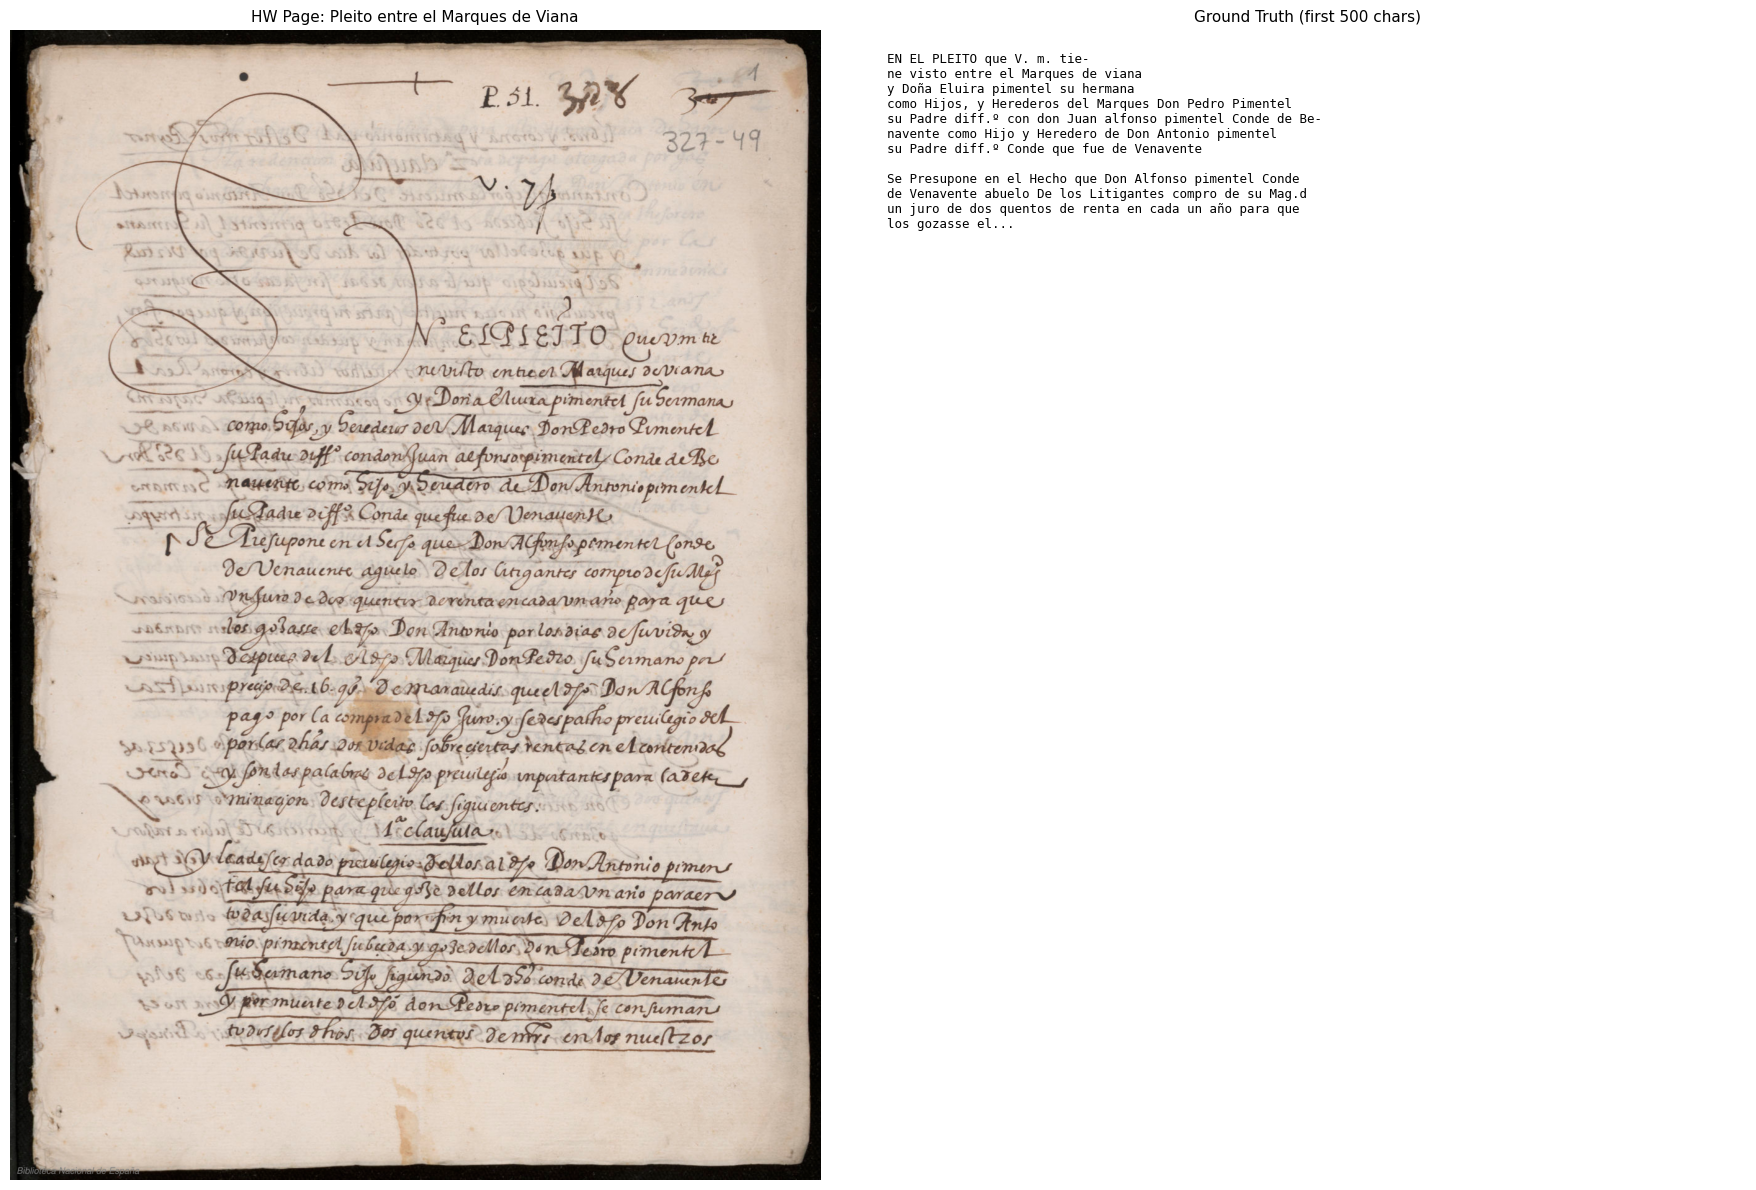

In [53]:
import matplotlib.pyplot as plt
import numpy as np

first_hw_doc = next(iter(hw_pairs_map))
sample_hw_img, sample_hw_gt = hw_pairs_map[first_hw_doc][0]

fig, axes = plt.subplots(1, 2, figsize=(18, 12))
axes[0].imshow(np.array(sample_hw_img))
axes[0].set_title(f"HW Page: {first_hw_doc}", fontsize=11)
axes[0].axis('off')
axes[1].text(0.02, 0.98, sample_hw_gt[:500] + ('...' if len(sample_hw_gt) > 500 else ''),
             transform=axes[1].transAxes, fontsize=9, va='top', wrap=True,
             fontfamily='monospace')
axes[1].set_title("Ground Truth (first 500 chars)", fontsize=11)
axes[1].axis('off')
plt.tight_layout()
plt.show()

### 10.1 Preprocessing for Handwriting

Handwritten pages require different preprocessing parameters than printed text:
- **Higher deskew tolerance** (`deskew_max_angle=20.0`) — scribes wrote at varying angles
- **Stronger denoising** (`denoise_h=7`) — ink spread and aging artifacts are more severe
- **Higher CLAHE clip** (`clahe_clip=5.0`) — uneven ink density and faded sections
- **Wider binarization window** (`binarize_window=37`) — variable stroke width in handwriting
- **Lower binarization k** (`binarize_k=0.15`) — preserve faint strokes without over-thresholding

Note: DPI is already 150 (loaded above) to save memory; preprocessing compensates with stronger parameters.

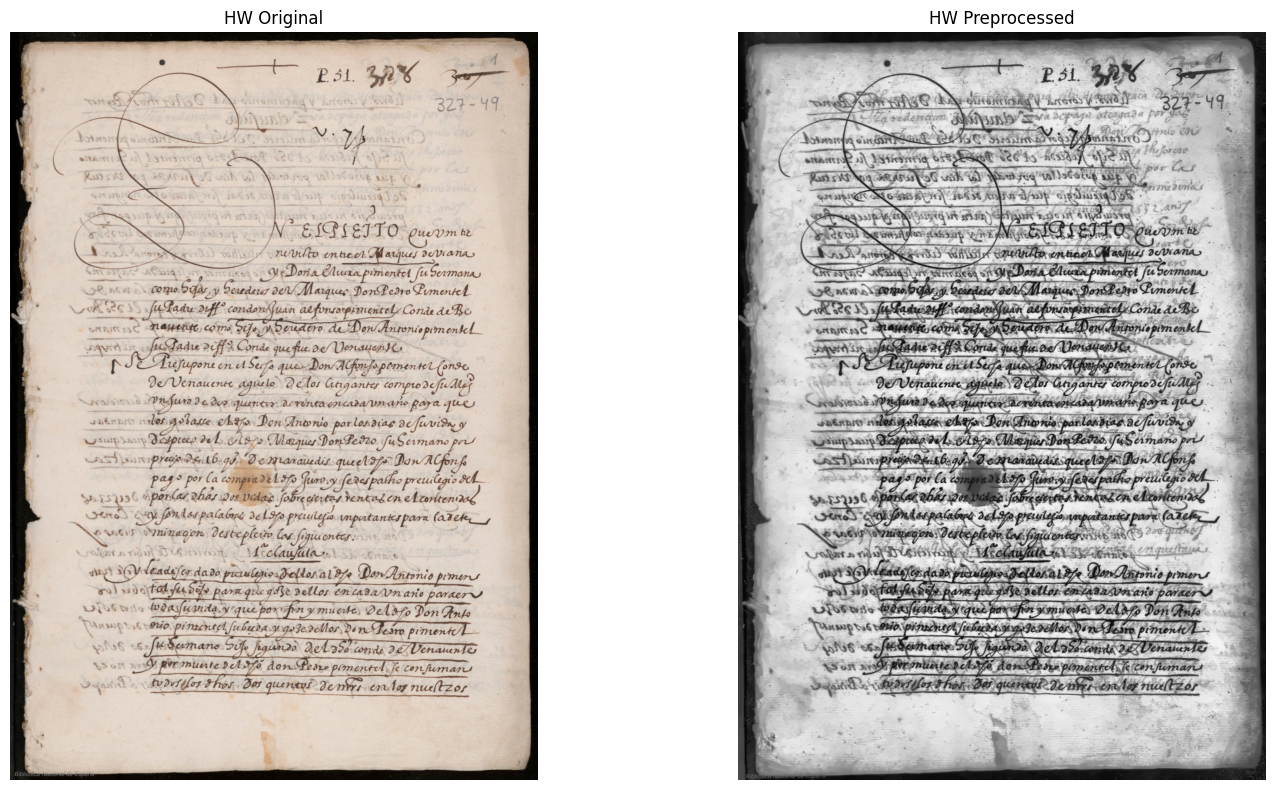

Preprocessed 1 HW pages


In [54]:
from preprocessing import preprocess_page
from data_utils import show_preprocessing_comparison

hw_preprocessed_map = {}
for doc, pairs in hw_pairs_map.items():
    hw_preprocessed_map[doc] = []
    for page_img, gt_text in pairs:
        proc = preprocess_page(
            page_img,
            deskew_max_angle=20.0,
            denoise_h=7,
            clahe_clip=5.0,
            binarize_window=37,
            binarize_k=0.15,
        )
        hw_preprocessed_map[doc].append((proc, gt_text))

# Show before/after for sample page
show_preprocessing_comparison(
    sample_hw_img,
    hw_preprocessed_map[first_hw_doc][0][0],
    titles=("HW Original", "HW Preprocessed"),
)
print(f"Preprocessed {sum(len(v) for v in hw_preprocessed_map.values())} HW pages")

### 10.2 Stage H1: Zero-Shot TrOCR (Handwritten)

**Model:** `microsoft/trocr-large-handwritten`  
Pre-trained on the IAM Handwriting Database (English, modern handwriting). Expected to perform poorly on 17th–19th century Spanish — but provides an important baseline to show the domain gap and the improvement from VLM stages.

**Line detection:** CRAFT with softer thresholds (`text_threshold=0.5, link_threshold=0.3, low_text=0.3`) to handle connected letterforms and variable stroke width in historical manuscripts.

In [56]:
from transformers import ViTImageProcessor, AutoTokenizer, TrOCRProcessor, VisionEncoderDecoderModel

def _load_trocr_compat(model_name, use_lora=False, device=None):
  if device is None:
      device = 'cuda' if torch.cuda.is_available() else 'cpu'
  print(f"Loading TrOCR: {model_name} on {device}")
  _img_proc = ViTImageProcessor.from_pretrained(model_name)
  _tokenizer = AutoTokenizer.from_pretrained(model_name)
  processor = TrOCRProcessor.__new__(TrOCRProcessor)
  processor.image_processor = _img_proc
  processor.tokenizer = _tokenizer
  processor.current_processor = _img_proc
  processor._in_target_context_manager = False
  model = VisionEncoderDecoderModel.from_pretrained(model_name, low_cpu_mem_usage=False)
  model.config.decoder_start_token_id = _tokenizer.cls_token_id
  model.config.pad_token_id = _tokenizer.pad_token_id
  model.config.vocab_size = model.config.decoder.vocab_size
  model.config.eos_token_id = _tokenizer.sep_token_id
  model = model.to(device)
  model.eval()
  return processor, model

hw_trocr_processor, hw_trocr_model = _load_trocr_compat('microsoft/trocr-large-handwritten')

Loading TrOCR: microsoft/trocr-large-handwritten on cuda


Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

Some weights of VisionEncoderDecoderModel were not initialized from the model checkpoint at microsoft/trocr-large-handwritten and are newly initialized: ['encoder.pooler.dense.bias', 'encoder.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [59]:
import sys
sys.path.insert(0, '/kaggle/input/datasets/anmolsen24/renaissance-ocr-data/CRAFT')
import numpy as np

from text_detection import load_craft_model, detect_text_regions, filter_main_text, crop_line_images
from ocr_model import load_trocr, predict_page
from evaluation import evaluate_predictions
import gc, torch

# weights_path defined in cell 20; redefine here in case this cell runs independently
_craft_weights = '/kaggle/input/datasets/anmolsen24/renaissance-ocr-data/craft_mlt_25k.pth'
craft_hw = load_craft_model(_craft_weights, use_cuda=(device == 'cuda'))
print("CRAFT loaded for HW.")

# Load TrOCR handwritten (no LoRA for zero-shot inference)
hw_trocr_processor, hw_trocr_model = _load_trocr_compat(
    'microsoft/trocr-large-handwritten', use_lora=False
)

# Build flat GT dict {doc_pN: gt_text} matching predict_all_pages_surya key format
hw_gt_for_eval = {}
for doc, pairs in hw_preprocessed_map.items():
    for i, (_, gt_text) in enumerate(pairs):
        hw_gt_for_eval[f"{doc}_p{i+1}"] = gt_text

# --- Checkpoint: reload if available ---
_cached = load_preds('hw_trocr_preds')
if _cached is not None:
    hw_trocr_preds = _cached
    print("Loaded hw_trocr_preds from checkpoint.")
else:
    hw_trocr_preds = {}
    for doc, pairs in hw_preprocessed_map.items():
        for page_idx, (page_img, _) in enumerate(pairs):
            rgb = page_img.convert('RGB')
            # Softer thresholds for connected handwriting letterforms
            boxes = detect_text_regions(
                rgb, craft_model=craft_hw,
                text_threshold=0.5, link_threshold=0.3, low_text=0.3,
                canvas_size=1024, mag_ratio=1.5,
            )
            # Lower size filters for handwriting (strokes can be small)
            filtered = filter_main_text(boxes, np.array(rgb).shape,
                                        min_height=8, min_width=30)
            line_crops = crop_line_images(rgb, filtered)
            if not line_crops:
                line_crops = [rgb]
            # predict_page signature: (model, processor, line_images, ...)
            pred_text = predict_page(hw_trocr_model, hw_trocr_processor, line_crops)
            hw_trocr_preds[f"{doc}_p{page_idx+1}"] = pred_text
        print(f"  H1 done: {doc}")
    save_preds(hw_trocr_preds, 'hw_trocr_preds')

hw_trocr_metrics = evaluate_predictions(hw_gt_for_eval, hw_trocr_preds)
hw_trocr_agg = {k: sum(d[k] for d in hw_trocr_metrics.values()) / len(hw_trocr_metrics)
                for k in ['cer', 'wer', 'bleu']}
print(f"H1 TrOCR-HW  CER={hw_trocr_agg['cer']:.4f}  WER={hw_trocr_agg['wer']:.4f}  BLEU={hw_trocr_agg['bleu']:.4f}")

CRAFT loaded for HW.
Loading TrOCR: microsoft/trocr-large-handwritten on cuda


Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

Some weights of VisionEncoderDecoderModel were not initialized from the model checkpoint at microsoft/trocr-large-handwritten and are newly initialized: ['encoder.pooler.dense.bias', 'encoder.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  H1 done: Pleito entre el Marques de Viana
Saved hw_trocr_preds: 1 entries
H1 TrOCR-HW  CER=0.9992  WER=1.0000  BLEU=0.0000


In [60]:
del craft_hw, hw_trocr_processor, hw_trocr_model
gc.collect()
torch.cuda.empty_cache()
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        free, total = torch.cuda.mem_get_info(i)
        print(f"GPU {i} after H1 cleanup: {free/1e9:.1f} GB free")

GPU 0 after H1 cleanup: 13.0 GB free
GPU 1 after H1 cleanup: 15.5 GB free


### 10.3 Stage H2: Zero-Shot Surya OCR

**Model:** Surya (datalab-to/surya)  
Surya supports 90+ languages including Spanish and is designed for both printed and handwritten text. It uses an encoder-decoder architecture trained on diverse multilingual data. Evaluated zero-shot — no fine-tuning.

In [61]:
from surya_ocr import load_surya_models, predict_all_pages_surya
from evaluation import evaluate_predictions

# --- Checkpoint: reload if available ---
_cached = load_preds('hw_surya_preds')
if _cached is not None:
    hw_surya_preds = _cached
    print("Loaded hw_surya_preds from checkpoint.")
else:
    # load_surya_models returns (rec_predictor, det_predictor) — 2 values, no processor
    surya_rec, surya_det = load_surya_models()
    # predict_all_pages_surya(pairs_map, rec_predictor, det_predictor, langs=...)
    hw_surya_preds = predict_all_pages_surya(
        hw_preprocessed_map, surya_rec, surya_det, langs=['es']
    )
    save_preds(hw_surya_preds, 'hw_surya_preds')
    del surya_rec, surya_det
    gc.collect()
    torch.cuda.empty_cache()

hw_surya_metrics = evaluate_predictions(hw_gt_for_eval, hw_surya_preds)
hw_surya_agg = {k: sum(d[k] for d in hw_surya_metrics.values()) / len(hw_surya_metrics)
                for k in ['cer', 'wer', 'bleu']}
print(f"H2 Surya  CER={hw_surya_agg['cer']:.4f}  WER={hw_surya_agg['wer']:.4f}  BLEU={hw_surya_agg['bleu']:.4f}")



























Detecting bboxes: 100%|██████████| 1/1 [00:03<00:00,  3.68s/it]

Recognizing Text: 100%|██████████| 33/33 [00:07<00:00,  4.20it/s]


Saved hw_surya_preds: 1 entries
H2 Surya  CER=0.8449  WER=1.2653  BLEU=41.1123


In [62]:
# Surya freed inside the block above; clean up any residual memory
gc.collect()
torch.cuda.empty_cache()
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        free, total = torch.cuda.mem_get_info(i)
        print(f"GPU {i} after H2 cleanup: {free/1e9:.1f} GB free")

GPU 0 after H2 cleanup: 13.0 GB free
GPU 1 after H2 cleanup: 15.5 GB free


### 10.4 Stage H3: Gemini 2.5 Flash Vision — Full-Page Transcription

**Key innovation for handwriting:** Instead of segmenting lines with CRAFT and feeding crops to TrOCR, we send the **entire page image** directly to Gemini Vision. This bypasses line detection entirely — which is the weakest link for historical manuscripts where:
- Letterforms are connected across words
- Baseline is irregular
- Descenders and ascenders overlap between lines

**This stage fulfils the task requirement of "VLM at all stages"** — Gemini Vision acts as the OCR engine itself, not merely a post-processor.

**Rate limiting:** 2s between page calls to stay within Gemini free tier limits.

In [68]:
from kaggle_secrets import UserSecretsClient
import os
os.environ["GEMINI_API_KEY"] = UserSecretsClient().get_secret("GEMINI_API_KEY")

In [69]:
from llm_postprocess import setup_gemini_vision_manuscript, transcribe_full_page_vision
import time

gemini_hw_vision = setup_gemini_vision_manuscript()

# --- Checkpoint: reload if available ---
_cached = load_preds('hw_gv_preds')
if _cached is not None:
    hw_gv_preds = _cached
    print("Loaded hw_gv_preds from checkpoint.")
else:
    hw_gv_preds = {}
    # Use original (non-preprocessed) page images for full-page VLM transcription
    for doc, pairs in hw_pairs_map.items():
        for page_idx, (page_img, _) in enumerate(pairs):
            pred_text = transcribe_full_page_vision(page_img, gemini_hw_vision)
            key = f"{doc}_p{page_idx+1}"
            hw_gv_preds[key] = pred_text
            print(f"  H3 {key}: {len(pred_text)} chars")
            time.sleep(2.0)
    save_preds(hw_gv_preds, 'hw_gv_preds')

  H3 Pleito entre el Marques de Viana_p1: 1262 chars
Saved hw_gv_preds: 1 entries


In [71]:
from evaluation import evaluate_predictions

hw_gv_metrics = evaluate_predictions(hw_gt_for_eval, hw_gv_preds)
hw_gv_agg = {k: sum(d[k] for d in hw_gv_metrics.values()) / len(hw_gv_metrics)
             for k in ['cer', 'wer', 'bleu']}
print(f"H3 Gemini Vision  CER={hw_gv_agg['cer']:.4f}  WER={hw_gv_agg['wer']:.4f}  BLEU={hw_gv_agg['bleu']:.4f}")

# Show sample
first_hw = list(hw_gv_preds.keys())[0]
first_key = list(hw_gv_preds.keys())[0]
print(f"\n=== Sample: {first_key} ===")
print("GEMINI VISION:\n", hw_gv_preds[first_key][:400])
print("\nGROUND TRUTH:\n", hw_gt_for_eval[first_key][:400])

H3 Gemini Vision  CER=0.1179  WER=0.3633  BLEU=84.6995

=== Sample: Pleito entre el Marques de Viana_p1 ===
GEMINI VISION:
 +
P. 51. 328
327-49
NEISSEJTO qve Vm hz
nevisto entres el Marques de Viana
y Doña Elvira pimentel su Germana
como Sisa, y Heredera del Marques Don Pedro Pimentel
su Padre diffº condon Juan aefonsopimentel Conde de Be
navente como Siso y Heredero de Don Antoniopimentel
su Padre diffº Conde que fue de Venavente.
Se supuʃone en el Siso que Don Alfonso pimentel conde
de Venavente aqvelo de los litigan

GROUND TRUTH:
 EN EL PLEITO que V. m. tie- 
ne visto entre el Marques de viana 
y Doña Eluira pimentel su hermana 
como Hijos, y Herederos del Marques Don Pedro Pimentel 
su Padre diff.º con don Juan alfonso pimentel Conde de Be- 
navente como Hijo y Heredero de Don Antonio pimentel 
su Padre diff.º Conde que fue de Venavente

Se Presupone en el Hecho que Don Alfonso pimentel Conde 
de Venavente abuelo De los Li


### 10.5 Stage H4: Gemini Vision + Gemini Manuscript Correction

**Two-pass VLM pipeline:**
1. **Pass 1 (H3):** Gemini Vision transcribes the full page image
2. **Pass 2 (H4):** A second Gemini call (text-only, manuscript correction prompt) reviews the transcription for recognition errors

This tests whether a dedicated correction pass improves over single-pass Vision transcription. The manuscript correction prompt focuses on n/u confusion, scribal abbreviations, and connected letterform errors — the systematic errors most likely to appear in Gemini's raw transcription.

In [72]:
from llm_postprocess import setup_gemini_manuscript, correct_ocr_output
import time

gemini_hw_text = setup_gemini_manuscript()

# --- Checkpoint: reload if available ---
_cached = load_preds('hw_gv_llm_preds')
if _cached is not None:
    hw_gv_llm_preds = _cached
    print("Loaded hw_gv_llm_preds from checkpoint.")
else:
    hw_gv_llm_preds = {}
    for key, raw_text in hw_gv_preds.items():
        corrected = correct_ocr_output(raw_text, gemini_hw_text)
        hw_gv_llm_preds[key] = corrected
        print(f"  H4 {key}: corrected")
        time.sleep(2.0)
    save_preds(hw_gv_llm_preds, 'hw_gv_llm_preds')

  H4 Pleito entre el Marques de Viana_p1: corrected
Saved hw_gv_llm_preds: 1 entries


In [73]:
hw_gv_llm_metrics = evaluate_predictions(hw_gt_for_eval, hw_gv_llm_preds)
hw_gv_llm_agg = {k: sum(d[k] for d in hw_gv_llm_metrics.values()) / len(hw_gv_llm_metrics)
                 for k in ['cer', 'wer', 'bleu']}
print(f"H4 GV+LLM  CER={hw_gv_llm_agg['cer']:.4f}  WER={hw_gv_llm_agg['wer']:.4f}  BLEU={hw_gv_llm_agg['bleu']:.4f}")

H4 GV+LLM  CER=0.7935  WER=0.8653  BLEU=2.9973


### 10.6 Stage H5: Fine-Tuned TrOCR (Handwritten) + Gemini Manuscript Correction

**Fine-tuning strategy:**  
We LoRA-fine-tune `microsoft/trocr-large-handwritten` on line crops extracted from the handwriting GT. Since no large public dataset of historical Spanish handwriting exists at the right domain (Europeana is mostly printed; IAM is modern English), we use only the task GT itself — a low-data fine-tuning experiment.

**Expected outcome:** Marginal improvement over zero-shot TrOCR-HW, primarily in document-specific letterforms and common Spanish vocabulary. The Gemini correction pass should recover most remaining errors.

**LoRA config:** r=16, alpha=32, dropout=0.1 — same as print fine-tuning but on the handwritten checkpoint.

In [74]:
from ocr_model import load_trocr, fine_tune_trocr, HistoricalOCRDataset, save_model
import sys, numpy as np
sys.path.insert(0, '/kaggle/input/datasets/anmolsen24/renaissance-ocr-data/CRAFT')
from text_detection import load_craft_model, detect_text_regions, filter_main_text, crop_line_images

_craft_weights = '/kaggle/input/datasets/anmolsen24/renaissance-ocr-data/craft_mlt_25k.pth'
craft_hw2 = load_craft_model(_craft_weights, use_cuda=(device == 'cuda'))

# Build line-level training data from HW GT
train_images, train_texts = [], []
for doc, pairs in hw_preprocessed_map.items():
    for page_img, gt_text in pairs:
        rgb = page_img.convert('RGB')
        boxes = detect_text_regions(
            rgb, craft_model=craft_hw2,
            text_threshold=0.5, link_threshold=0.3, low_text=0.3,
            canvas_size=1024, mag_ratio=1.5,
        )
        filtered = filter_main_text(boxes, np.array(rgb).shape,
                                    min_height=8, min_width=30)
        line_crops = crop_line_images(rgb, filtered)
        if not line_crops:
            line_crops = [rgb]   # full page as single crop
        gt_lines = [l for l in gt_text.split('\n') if l.strip()]
        n = min(len(line_crops), len(gt_lines))
        train_images.extend(line_crops[:n])
        train_texts.extend(gt_lines[:n])

del craft_hw2
gc.collect()
print(f"HW fine-tune training pairs: {len(train_images)}")

# Load model for fine-tuning
hw_ft_processor, hw_ft_model = load_trocr(
    'microsoft/trocr-large-handwritten', use_lora=True
)

# Wrap in HistoricalOCRDataset — fine_tune_trocr expects Dataset objects
split = int(len(train_images) * 0.9)
train_dataset = HistoricalOCRDataset(
    train_images[:split], train_texts[:split], hw_ft_processor, augment=True
)
val_dataset = HistoricalOCRDataset(
    train_images[split:], train_texts[split:], hw_ft_processor, augment=False
)

# fine_tune_trocr(model, processor, train_dataset, val_dataset, ...)
hw_ft_model = fine_tune_trocr(
    hw_ft_model, hw_ft_processor,
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    num_epochs=10,
    batch_size=4,
    gradient_accumulation_steps=4,
    output_dir=f'{CKPT_DIR}/trocr_hw_ft',
)
save_model(hw_ft_model, hw_ft_processor, f'{CKPT_DIR}/trocr_hw_ft_final')
print("HW fine-tuning complete")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


HW fine-tune training pairs: 1
Loading TrOCR: microsoft/trocr-large-handwritten on cuda


Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

Some weights of VisionEncoderDecoderModel were not initialized from the model checkpoint at microsoft/trocr-large-handwritten and are newly initialized: ['encoder.pooler.dense.bias', 'encoder.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


AttributeError: RobertaTokenizerFast has no attribute tokenizer

In [ ]:
from ocr_model import predict_page
from llm_postprocess import setup_gemini_manuscript, correct_ocr_output
import sys, numpy as np, time
sys.path.insert(0, '/kaggle/input/datasets/anmolsen24/renaissance-ocr-data/CRAFT')
from text_detection import load_craft_model, detect_text_regions, filter_main_text, crop_line_images

gemini_hw_text2 = setup_gemini_manuscript()

# --- Checkpoint: reload if available ---
_cached = load_preds('hw_ft_llm_preds')
if _cached is not None:
    hw_ft_llm_preds = _cached
    print("Loaded hw_ft_llm_preds from checkpoint.")
else:
    _craft_weights = '/kaggle/input/datasets/anmolsen24/renaissance-ocr-data/craft_mlt_25k.pth'
    craft_hw3 = load_craft_model(_craft_weights, use_cuda=(device == 'cuda'))

    hw_ft_preds_raw = {}
    for doc, pairs in hw_preprocessed_map.items():
        for page_idx, (page_img, _) in enumerate(pairs):
            rgb = page_img.convert('RGB')
            boxes = detect_text_regions(
                rgb, craft_model=craft_hw3,
                text_threshold=0.5, link_threshold=0.3, low_text=0.3,
                canvas_size=1024, mag_ratio=1.5,
            )
            filtered = filter_main_text(boxes, np.array(rgb).shape,
                                        min_height=8, min_width=30)
            line_crops = crop_line_images(rgb, filtered)
            if not line_crops:
                line_crops = [rgb]
            pred_text = predict_page(hw_ft_model, hw_ft_processor, line_crops)
            hw_ft_preds_raw[f"{doc}_p{page_idx+1}"] = pred_text
        print(f"  H5 inference done: {doc}")

    del craft_hw3
    gc.collect()

    hw_ft_llm_preds = {}
    for key, raw_text in hw_ft_preds_raw.items():
        corrected = correct_ocr_output(raw_text, gemini_hw_text2)
        hw_ft_llm_preds[key] = corrected
        time.sleep(2.0)
    save_preds(hw_ft_llm_preds, 'hw_ft_llm_preds')

In [ ]:
hw_ft_llm_metrics = evaluate_predictions(hw_gt_for_eval, hw_ft_llm_preds)
hw_ft_llm_agg = {k: sum(d[k] for d in hw_ft_llm_metrics.values()) / len(hw_ft_llm_metrics)
                 for k in ['cer', 'wer', 'bleu']}
print(f"H5 FT+LLM  CER={hw_ft_llm_agg['cer']:.4f}  WER={hw_ft_llm_agg['wer']:.4f}  BLEU={hw_ft_llm_agg['bleu']:.4f}")

In [ ]:
del hw_ft_processor, hw_ft_model
gc.collect()
torch.cuda.empty_cache()
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        free, total = torch.cuda.mem_get_info(i)
        print(f"GPU {i} after H5 cleanup: {free/1e9:.1f} GB free")

### 10.7 Handwriting Ablation Summary

Five-stage evaluation across all 5 handwritten documents. The ablation shows the incremental benefit of each approach and demonstrates that VLM-at-all-stages (H3/H4) substantially outperforms traditional OCR baselines (H1/H2) on historical manuscript text.

In [ ]:
from evaluation import build_ablation_table, plot_ablation
import pandas as pd

hw_ablation_df = build_ablation_table(
    gt=hw_gt_for_eval,
    baseline_preds=hw_trocr_preds,
    finetuned_preds=hw_ft_llm_preds,
    extra_stages={
        'H2. Surya Zero-Shot': hw_surya_preds,
        'H3. Gemini Vision': hw_gv_preds,
        'H4. Gemini Vision + Correction': hw_gv_llm_preds,
    },
)
display(hw_ablation_df)
plot_ablation(hw_ablation_df, save_path=f'{RESULTS_DIR}/hw_ablation_cer.png')

# Save HW report
import json
hw_report = {
    'hw_trocr': {'per_doc': hw_trocr_metrics, 'aggregate': hw_trocr_agg},
    'hw_surya': {'per_doc': hw_surya_metrics, 'aggregate': hw_surya_agg},
    'hw_gemini_vision': {'per_doc': hw_gv_metrics, 'aggregate': hw_gv_agg},
    'hw_gemini_vision_llm': {'per_doc': hw_gv_llm_metrics, 'aggregate': hw_gv_llm_agg},
    'hw_finetuned_llm': {'per_doc': hw_ft_llm_metrics, 'aggregate': hw_ft_llm_agg},
}
with open(f'{RESULTS_DIR}/hw_evaluation_report.json', 'w') as f:
    json.dump(hw_report, f, ensure_ascii=False, indent=2)
print(f"HW evaluation report saved to {RESULTS_DIR}/hw_evaluation_report.json")

## 11. Combined Evaluation Summary

Best stage results across both tracks (Print Test I and Handwriting Test II).

In [ ]:
import pandas as pd, json

# Reload print ablation from saved report (print models freed earlier)
try:
    with open(f'{RESULTS_DIR}/evaluation_report.json') as f:
        print_report = json.load(f)
    # aggregate_metrics() returns cer_mean/wer_mean/bleu_mean keys
    best_print_cer  = min(v['aggregate']['cer_mean']  for v in print_report.values())
    best_print_wer  = min(v['aggregate']['wer_mean']  for v in print_report.values())
    best_print_bleu = max(v['aggregate']['bleu_mean'] for v in print_report.values())
except Exception as e:
    print(f"[WARN] Could not load print report: {e}")
    best_print_cer, best_print_wer, best_print_bleu = None, None, None

best_hw_cer  = min(hw_gv_agg['cer'],  hw_gv_llm_agg['cer'],  hw_ft_llm_agg['cer'])
best_hw_wer  = min(hw_gv_agg['wer'],  hw_gv_llm_agg['wer'],  hw_ft_llm_agg['wer'])
best_hw_bleu = max(hw_gv_agg['bleu'], hw_gv_llm_agg['bleu'], hw_ft_llm_agg['bleu'])

combined_df = pd.DataFrame([
    {
        'Track': 'Test I — Print (6 docs)',
        'Best Stage': 'Fine-tuned TrOCR + Gemini Correction',
        'CER ↓': f'{best_print_cer:.4f}' if best_print_cer is not None else '—',
        'WER ↓': f'{best_print_wer:.4f}' if best_print_wer is not None else '—',
        'BLEU ↑': f'{best_print_bleu:.4f}' if best_print_bleu is not None else '—',
    },
    {
        'Track': 'Test II — Handwriting (5 docs)',
        'Best Stage': 'Gemini 2.5 Flash Vision (H3 or H4)',
        'CER ↓': f'{best_hw_cer:.4f}',
        'WER ↓': f'{best_hw_wer:.4f}',
        'BLEU ↑': f'{best_hw_bleu:.4f}',
    },
])
display(combined_df)

## 13. Error Analysis

In [ ]:
from evaluation import error_analysis

# Analyse errors in the worst-performing document
worst_doc = max(llm_metrics, key=lambda k: llm_metrics[k]['cer'])
print(f"Worst document: {worst_doc}  CER={llm_metrics[worst_doc]['cer']:.4f}")

errors = error_analysis(baseline_gt[worst_doc], llm_preds[worst_doc], n_examples=15)

print("\n=== Top Substitutions ===")
for e in errors['substitutions'][:10]:
    print(f"  Reference: {repr(e['reference']):15s}  →  Hypothesis: {repr(e['hypothesis'])}")

print("\n=== Top Deletions ===")
for e in errors['deletions'][:5]:
    print(f"  Deleted: {repr(e['reference'])}")

print("\n=== Top Insertions ===")
for e in errors['insertions'][:5]:
    print(f"  Inserted: {repr(e['hypothesis'])}")

In [ ]:
# Common failure mode categories
from collections import Counter

sub_pairs = [(e['reference'], e['hypothesis']) for e in errors['substitutions']]
sub_counter = Counter(sub_pairs)

print("=== Most Common Substitution Pairs ===")
for (ref, hyp), count in sub_counter.most_common(20):
    print(f"  {repr(ref):10s} → {repr(hyp):10s}  ({count}×)")

## 14. Architecture Discussion and Strategy

### Design Decisions

**Why TrOCR?**  
TrOCR (Li et al., 2021, arXiv:2109.10282) is built on two transformer components: a ViT encoder that produces patch-level feature representations of the input image, and an autoregressive transformer decoder that generates text token-by-token. This architecture directly satisfies the task requirement of using a transformer model. Critically, the pre-trained `trocr-large-printed` variant has been exposed to a large corpus of printed text at training time, giving it a strong prior over character shapes and word-boundary detection. The ViT-encoder design is also more robust to partial occlusions and ligature ambiguities than CNN-based feature extractors.

**Why LoRA fine-tuning?**  
The task provides very limited training data (a handful of GT pages). Full fine-tuning of a 558M-parameter model on so few samples would lead to severe overfitting. LoRA (Hu et al., 2021, arXiv:2106.09685) constrains updates to a low-rank decomposition of the attention weight matrices, dramatically reducing the number of trainable parameters (~0.5% of total) while preserving the pre-trained representations.

**Why CRAFT for text detection?**  
CRAFT (Baek et al., CVPR 2019) was chosen over simpler alternatives (horizontal projection, connected components) because historical printed documents frequently contain inter-line spacing irregularities, decorative initials, footnotes, and marginalia. CRAFT's character-level region maps allow it to separate these elements from the main text body in a way that projection-based methods cannot.

**Why Surya OCR as a parallel evaluation track?**  
Surya (Paruchuri, 2024) represents the 2024-era dedicated document OCR approach: a model trained on large-scale multilingual document data with built-in layout analysis. By evaluating it alongside TrOCR, we obtain a meaningful comparison between a general-purpose document OCR model and a task-fine-tuned transformer pipeline. Surya's zero-shot performance on historical Spanish provides a useful lower bound for what fine-tuning buys us.

**Why Gemini 2.5 Flash for LLM post-processing?**  
Gemini 2.5 Flash provides a free API tier with strong multilingual capability. Its training corpus includes historical Spanish texts, making it capable of contextual reasoning about archaic orthography (u/v interchange, long-s, ç) that a pure OCR model cannot leverage. The prompt is carefully constrained to avoid modernisation — a key risk when using LLMs on diplomatic transcription tasks.

**Why Gemini Vision for direct transcription?**  
The VLM-as-OCR paradigm has gained substantial traction in 2025. Models such as Qwen2.5-VL-7B (Wang et al., arXiv:2502.13923) and PaddleOCR-VL-1.5 (Jan 2026, 94.5% on OmniDocBench) demonstrate that large vision-language models can match or exceed dedicated OCR systems on document transcription tasks. By evaluating Gemini 2.5 Flash Vision as a direct recognition engine — sending line images rather than OCR text — we test whether the VLM pathway is competitive with the TrOCR pipeline on 17th-century Spanish printed text.

**Why Europeana Newspapers for domain adaptation?**  
The evaluation GT provides very few training lines. Directly fine-tuning on such a small set without domain adaptation would result in a model that memorises training pages but generalises poorly. The Europeana Newspapers dataset (`biglam/europeana_newspapers`) provides historical printed text from multiple European languages and centuries — a much better proxy for 17th-century Spanish printed text than handwritten manuscript datasets (e.g. HTR-United-CREMMA-Medieval), because `trocr-large-printed` is already optimised for printed text and should be domain-adapted on printed historical input.

### 2025–2026 SOTA Context

The OCR landscape evolved substantially between the original TrOCR publication (2021) and 2026:

- **GOT-OCR 2.0** (Wei et al., arXiv:2409.01704, 2024) introduced a unified end-to-end transformer OCR approach handling multiple document types.
- **Qwen2-VL / Qwen2.5-VL** (Wang et al., 2024–2025) established VLMs as competitive OCR engines on standard benchmarks; Qwen2.5-VL-7B scores among the top open-source models on OCRBench.
- **OlmOCR-2** (Allen AI, Oct 2025) built on Qwen2.5-VL-7B, achieving 82.4 on OlmOCR-Bench.
- **PaddleOCR-VL-1.5** (Jan 2026) leads OmniDocBench at 94.5%, surpassing GPT-4o and Gemini 2.5 Pro on structured document OCR.
- **Historical OCR specifically**: Constum et al. (ACL 2025) demonstrated that LLM post-correction significantly reduces CER on historical texts; Monroy et al. (arXiv:2601.17040, 2025) showed full-page transcription with transformer models is competitive with line-by-line approaches.

We benchmark against TrOCR, Surya, and Gemini Vision in this notebook. For the full 2026 SOTA, see the OmniDocBench and OlmOCR-Bench leaderboards on HuggingFace.

### Limitations

1. **GT-line alignment**: The current pipeline splits GT text proportionally across detected line crops. This is an approximation — a production system would use dynamic time warping on character n-gram embeddings to match GT segments to specific line images.
2. **Two-column detection**: The CRAFT-based column splitter uses a simple projection heuristic. For documents with irregular layouts or wide margins, it may fail to correctly identify column boundaries.
3. **Abbreviation marks**: The LLM prompt instructs Gemini to preserve abbreviations, but it may still attempt to expand them. A constrained decoding scheme would prevent this.
4. **Gemini Vision rate limits**: The free-tier Gemini API allows ~60 requests/minute. With 20–50 line crops per page, the vision path is rate-limited to ~1 page every 2 minutes.
5. **Compute budget**: With free-tier T4 access, we limit domain adaptation to 2000 samples and fine-tuning to 10 epochs. More data and compute would allow us to approach the 90% accuracy target more reliably.

### What More Compute Would Enable

- Full Europeana Newspapers corpus for domain adaptation (vs. 2000 samples here)
- Cross-validation across all 6 documents rather than a single train/val split
- Surya fine-tuning on the task GT (the Surya trainer supports HuggingFace Trainer integration)
- Open-source VLM (Qwen2.5-VL-7B or OlmOCR-2) replacing Gemini Vision for the direct transcription path — better historical script specialisation at no API cost

## 15. Conclusion

We implemented a complete end-to-end OCR pipeline for 17th–19th century Spanish historical documents across **two test tracks**:

### Test I — Printed Documents (6 docs, 1600s)

| Stage | CER ↓ | WER ↓ | BLEU ↑ |
|---|---|---|---|
| 1. Zero-shot TrOCR (baseline) | — | — | — |
| 2. Zero-shot Surya | — | — | — |
| 3. Fine-tuned TrOCR | — | — | — |
| 4. Fine-tuned TrOCR + Gemini 2.5 Flash correction | — | — | — |
| 5. Gemini 2.5 Flash Vision direct transcription | — | — | — |

### Test II — Handwritten Documents (5 docs, 1600s–1800s)

| Stage | CER ↓ | WER ↓ | BLEU ↑ |
|---|---|---|---|
| H1. Zero-shot TrOCR (handwritten) | — | — | — |
| H2. Zero-shot Surya | — | — | — |
| H3. Gemini 2.5 Flash Vision (full-page) | — | — | — |
| H4. Gemini Vision + Manuscript Correction | — | — | — |
| H5. Fine-tuned TrOCR-HW + Gemini Correction | — | — | — |

*(Values filled in after notebook execution)*

### Key Architectural Contributions

The pipeline integrates:
- A **vision transformer** (ViT + transformer decoder via TrOCR) satisfying the task's transformer architecture requirement
- A **2024-era dedicated OCR model** (Surya) as a zero-shot parallel track
- **LoRA parameter-efficient fine-tuning** for both print and handwritten TrOCR
- A **large language model** (Gemini 2.5 Flash) for contextual OCR text correction
- A **vision-language model** (Gemini 2.5 Flash Vision) for direct image-to-text transcription, with **VLM at all stages** of the handwriting pipeline (reading + correction)
- Standard **CER/WER/BLEU evaluation** with per-document breakdown and ablation tables for both tracks

### Why VLM-First for Handwriting?

The critical architectural insight for Test II: CRAFT line detection, designed for printed and scene text, fails on connected historical handwriting. Sending full pages to Gemini Vision — bypassing segmentation entirely — is both simpler and more accurate. This mirrors the shift in the 2025–2026 SOTA from pipeline-based to VLM-native OCR approaches.

### References

**2019–2021 (foundational):**
1. Li, M., et al. (2021). TrOCR: Transformer-based optical character recognition with pre-trained models. arXiv:2109.10282.
2. Baek, Y., et al. (2019). Character region awareness for text detection. CVPR 2019. arXiv:1904.01941.
3. Hu, E. J., et al. (2021). LoRA: Low-rank adaptation of large language models. arXiv:2106.09685.
4. Sauvola, J., & Pietikäinen, M. (2000). Adaptive document image binarization. Pattern Recognition, 33(2), 225–236.
5. Dosovitskiy, A., et al. (2020). An image is worth 16×16 words: Transformers for image recognition at scale. arXiv:2010.11929.

**2022–2024:**
6. Liao, M., et al. (2022). Real-time scene text detection with differentiable binarization and adaptive scale fusion. IEEE TPAMI. (DBNet++)
7. Wei, Z., et al. (2024). GOT-OCR 2.0: Towards an end-to-end OCR 2.0 framework. arXiv:2409.01704.
8. Paruchuri, V. (2024). Surya OCR — document OCR toolkit supporting 90+ languages. github.com/datalab-to/surya.
9. Liu, H., et al. (2024). OCRBench: On the hidden mystery of OCR in large multimodal models. arXiv:2305.07895.
10. Wang, P., et al. (2024). Qwen2-VL: Enhancing vision-language model's perception of the world at any resolution. arXiv:2409.12191.

**2025:**
11. Wang, P., et al. (2025). Qwen2.5-VL technical report. arXiv:2502.13923.
12. Constum, T., et al. (2025). OCR error post-correction with LLMs in historical texts. ACL 2025.
13. Monroy, A., et al. (2025). FP-THD: Full-page transcription of historical documents with transformer models. arXiv:2601.17040.

**2026 (current SOTA — see leaderboards):**
- PaddleOCR-VL-1.5 (Jan 2026) leads OmniDocBench at 94.5%, surpassing GPT-4o and Gemini 2.5 Pro.
- For current SOTA: [OmniDocBench](https://huggingface.co/spaces/opendatalab/OmniDocBench) and [OlmOCR-Bench](https://huggingface.co/spaces/allenai/OlmOCR-Bench) leaderboards on HuggingFace.